<a href="https://colab.research.google.com/github/vsmakwana2001-ux1/NMPC_PID_Controller_GDP/blob/main/Copy_of_Tutorial_4_Object_Detection_using_Pre_trained_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== Common tiny helpers (optional) =====
import cv2, numpy as np, requests
from pathlib import Path

def download(url: str, dest: str):
    p = Path(dest); p.parent.mkdir(parents=True, exist_ok=True)
    if not p.exists():
        r = requests.get(url, stream=True); r.raise_for_status()
        with open(p, "wb") as f:
            for ch in r.iter_content(1<<20):
                if ch: f.write(ch)
    return str(p)

def draw_boxes(img, boxes_xyxy, scores, class_ids, names):
    out = img.copy()
    for (x1,y1,x2,y2), s, c in zip(boxes_xyxy, scores, class_ids):
        cv2.rectangle(out, (x1,y1),(x2,y2),(0,255,0),2)
        label = f"{names[c]} {s:.2f}"
        (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX,0.5,1)
        cv2.rectangle(out,(x1,y1-th-6),(x1+tw+4,y1),(0,255,0),-1)
        cv2.putText(out,label,(x1+2,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,0),1)
    return out


# Loading the YOLOv4

This section demonstrates how to use **YOLOv4 (You Only Look Once, version 4)** for object detection using OpenCV Deep Neural Network (DNN) module.

* It begins by defining the COCO dataset 80 object categories, such as person, car, and dog, which YOLOv4 is trained to recognize.
* The configuration (`.cfg`) and pretrained weights (`.weights`) files are automatically downloaded using the helper function from before, along with a sample test image.
* Then the YOLOv4 network is loaded with `cv2.dnn.readNetFromDarknet()` and prepares the image into a **blob**, which is a standardized format for deep learning inference (resized, normalized, and channel-adjusted).
* The network performs a forward pass to generate predictions, from which the code extracts bounding box coordinates, class IDs, and confidence scores—filtering only detections above a threshold of 0.25.
* It then applies Non-Maximum Suppression (NMS) to remove overlapping boxes, keeping the most confident ones.
* Finally, the results are visualized using the earlier `draw_boxes()` function and saved.


This workflow effectively illustrates the full YOLOv4 detection pipeline—from model loading to inference and visualization—ideal for teaching real-world computer vision concepts.

Detected 7 pedestrians
Saved result -> out/pedestrian_detection.jpg


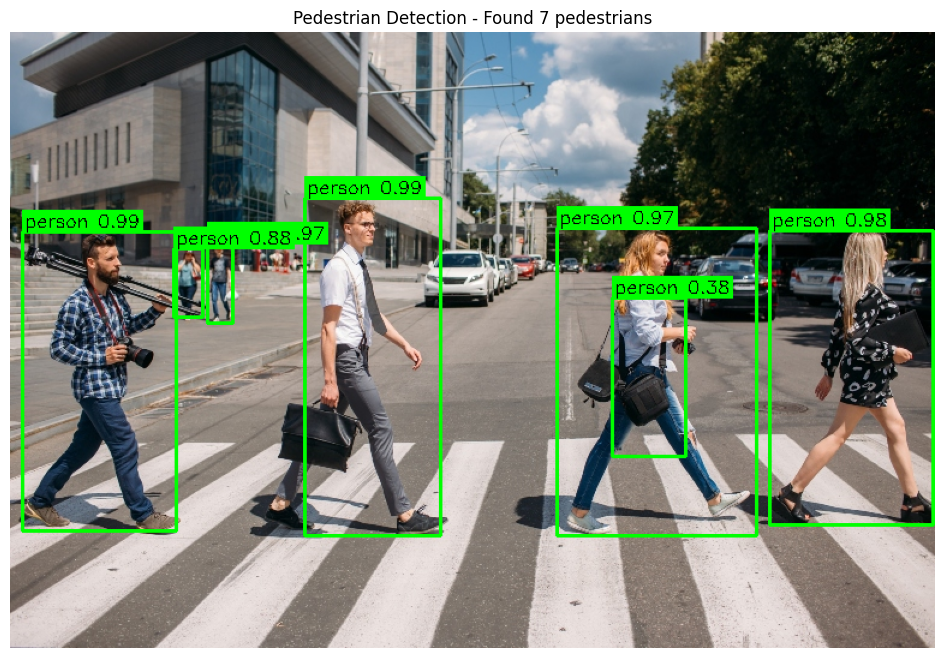


Detailed detection information:
Pedestrian 1: BBox [10, 166, 138, 415], Confidence: 0.992
Pedestrian 2: BBox [245, 138, 358, 419], Confidence: 0.987
Pedestrian 3: BBox [632, 165, 768, 410], Confidence: 0.976
Pedestrian 4: BBox [455, 163, 621, 419], Confidence: 0.973
Pedestrian 5: BBox [164, 176, 185, 242], Confidence: 0.969
Pedestrian 6: BBox [136, 180, 160, 237], Confidence: 0.883
Pedestrian 7: BBox [501, 221, 562, 353], Confidence: 0.381


In [ ]:
# ===== Common tiny helpers =====
import cv2
import numpy as np
import requests
from pathlib import Path
import matplotlib.pyplot as plt

def download(url: str, dest: str):
    p = Path(dest); p.parent.mkdir(parents=True, exist_ok=True)
    if not p.exists():
        r = requests.get(url, stream=True); r.raise_for_status()
        with open(p, "wb") as f:
            for ch in r.iter_content(1<<20):
                if ch: f.write(ch)
    return str(p)

def draw_boxes(img, boxes_xyxy, scores, class_ids, names):
    out = img.copy()
    for (x1,y1,x2,y2), s, c in zip(boxes_xyxy, scores, class_ids):
        cv2.rectangle(out, (x1,y1),(x2,y2),(0,255,0),2)
        label = f"{names[c]} {s:.2f}"
        (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX,0.5,1)
        cv2.rectangle(out,(x1,y1-th-6),(x1+tw+4,y1),(0,255,0),-1)
        cv2.putText(out,label,(x1+2,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,0),1)
    return out

# ===== YOLOv4 Pedestrian Detection =====

# COCO dataset class names (index 0 is 'person')
COCO = ['person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light',
        'fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant','bear',
        'zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
        'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass','cup',
        'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
        'cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard',
        'cell phone','microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
        'hair drier','toothbrush']

def detect_pedestrians(image_path):
    """
    Detect pedestrians in an image using YOLOv4
    Returns: image with bounding boxes, pedestrian count, and detection data
    """
    # Download model files if not exists
    cfg = download("https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg", "weights/yolov4.cfg")
    wts = download("https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4.weights", "weights/yolov4.weights")

    # Load YOLOv4 network
    net = cv2.dnn.readNetFromDarknet(cfg, wts)

    # Read input image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")

    H, W = img.shape[:2]

    # Preprocess image
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (608,608), swapRB=True, crop=False)
    net.setInput(blob)

    # Forward pass
    outs = net.forward(net.getUnconnectedOutLayersNames())

    # Parse detections
    boxes_xyxy, scores, class_ids = [], [], []
    for out in outs:
        for det in out:
            confs = det[5:]
            cid = int(np.argmax(confs))
            score = float(det[4] * confs[cid])

            # Only keep detections with confidence >= 0.25 and class 'person' (class_id = 0)
            if score >= 0.25 and cid == 0:
                cx, cy, bw, bh = det[0]*W, det[1]*H, det[2]*W, det[3]*H
                x1, y1 = int(cx - bw/2), int(cy - bh/2)
                boxes_xyxy.append((x1,y1,int(x1+bw),int(y1+bh)))
                scores.append(score)
                class_ids.append(cid)

    # Apply Non-Maximum Suppression
    if boxes_xyxy:
        idxs = cv2.dnn.NMSBoxes(
            [(x1,y1,x2-x1,y2-y1) for (x1,y1,x2,y2) in boxes_xyxy],
            scores,
            0.25,  # score threshold
            0.45   # NMS IoU threshold
        )

        keep = idxs.flatten().tolist() if hasattr(idxs,"flatten") and len(idxs)>0 else list(range(len(scores)))
        boxes_xyxy = [boxes_xyxy[i] for i in keep]
        scores = [scores[i] for i in keep]
        class_ids = [class_ids[i] for i in keep]

    # Draw bounding boxes
    vis = draw_boxes(img, boxes_xyxy, scores, class_ids, COCO)

    return vis, len(boxes_xyxy), boxes_xyxy, scores

# ===== Main execution =====
if __name__ == "__main__":
    # Example usage with different image sources:

    # Option 1: Use a sample pedestrian image
    sample_img_path = download("https://callsam.com/wp-content/uploads/2019/12/crosswalk-featured.jpg", "data/pedestrian_sample.jpg")

    # Option 2: Replace with your own image path
    # sample_img_path = "path/to/your/image.jpg"

    # Detect pedestrians
    result_img, pedestrian_count, boxes, scores = detect_pedestrians(sample_img_path)

    # Save and display results
    output_path = "out/pedestrian_detection.jpg"
    cv2.imwrite(output_path, result_img)

    # Display results
    print(f"Detected {pedestrian_count} pedestrians")
    print(f"Saved result -> {output_path}")

    # Convert BGR to RGB for matplotlib
    result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    # Create visualization
    plt.figure(figsize=(12, 8))
    plt.imshow(result_rgb)
    plt.axis('off')
    plt.title(f"Pedestrian Detection - Found {pedestrian_count} pedestrians")
    plt.show()

    # Print detailed detection information
    if pedestrian_count > 0:
        print("\nDetailed detection information:")
        for i, (box, score) in enumerate(zip(boxes, scores)):
            x1, y1, x2, y2 = box
            print(f"Pedestrian {i+1}: BBox [{x1}, {y1}, {x2}, {y2}], Confidence: {score:.3f}")

Step 1: Detecting all objects with YOLO...
YOLO detected 87 objects total
Step 2: Simulating radar for all object categories...
Step 3: Applying DBSCAN clustering...

=== YOLO DETECTION RESULTS ===
Pedestrians detected: 34
Vehicles detected: 42
Other objects detected: 11

=== RADAR CLUSTERING RESULTS ===
Total DBSCAN clusters: 1
Vehicle clusters: 1

=== CLUSTER DETAILS ===
Cluster 1: Vehicle
  - Center: (381.4, 287.7)
  - Size: 5029 points
  - BBox: [0.0, 42.8, 543.0, 415.4]
  - Composition: {np.int64(0): np.int64(1353), np.int64(1): np.int64(3360), np.int64(2): np.int64(275), np.int64(3): np.int64(41)}

Generating comprehensive visualization...


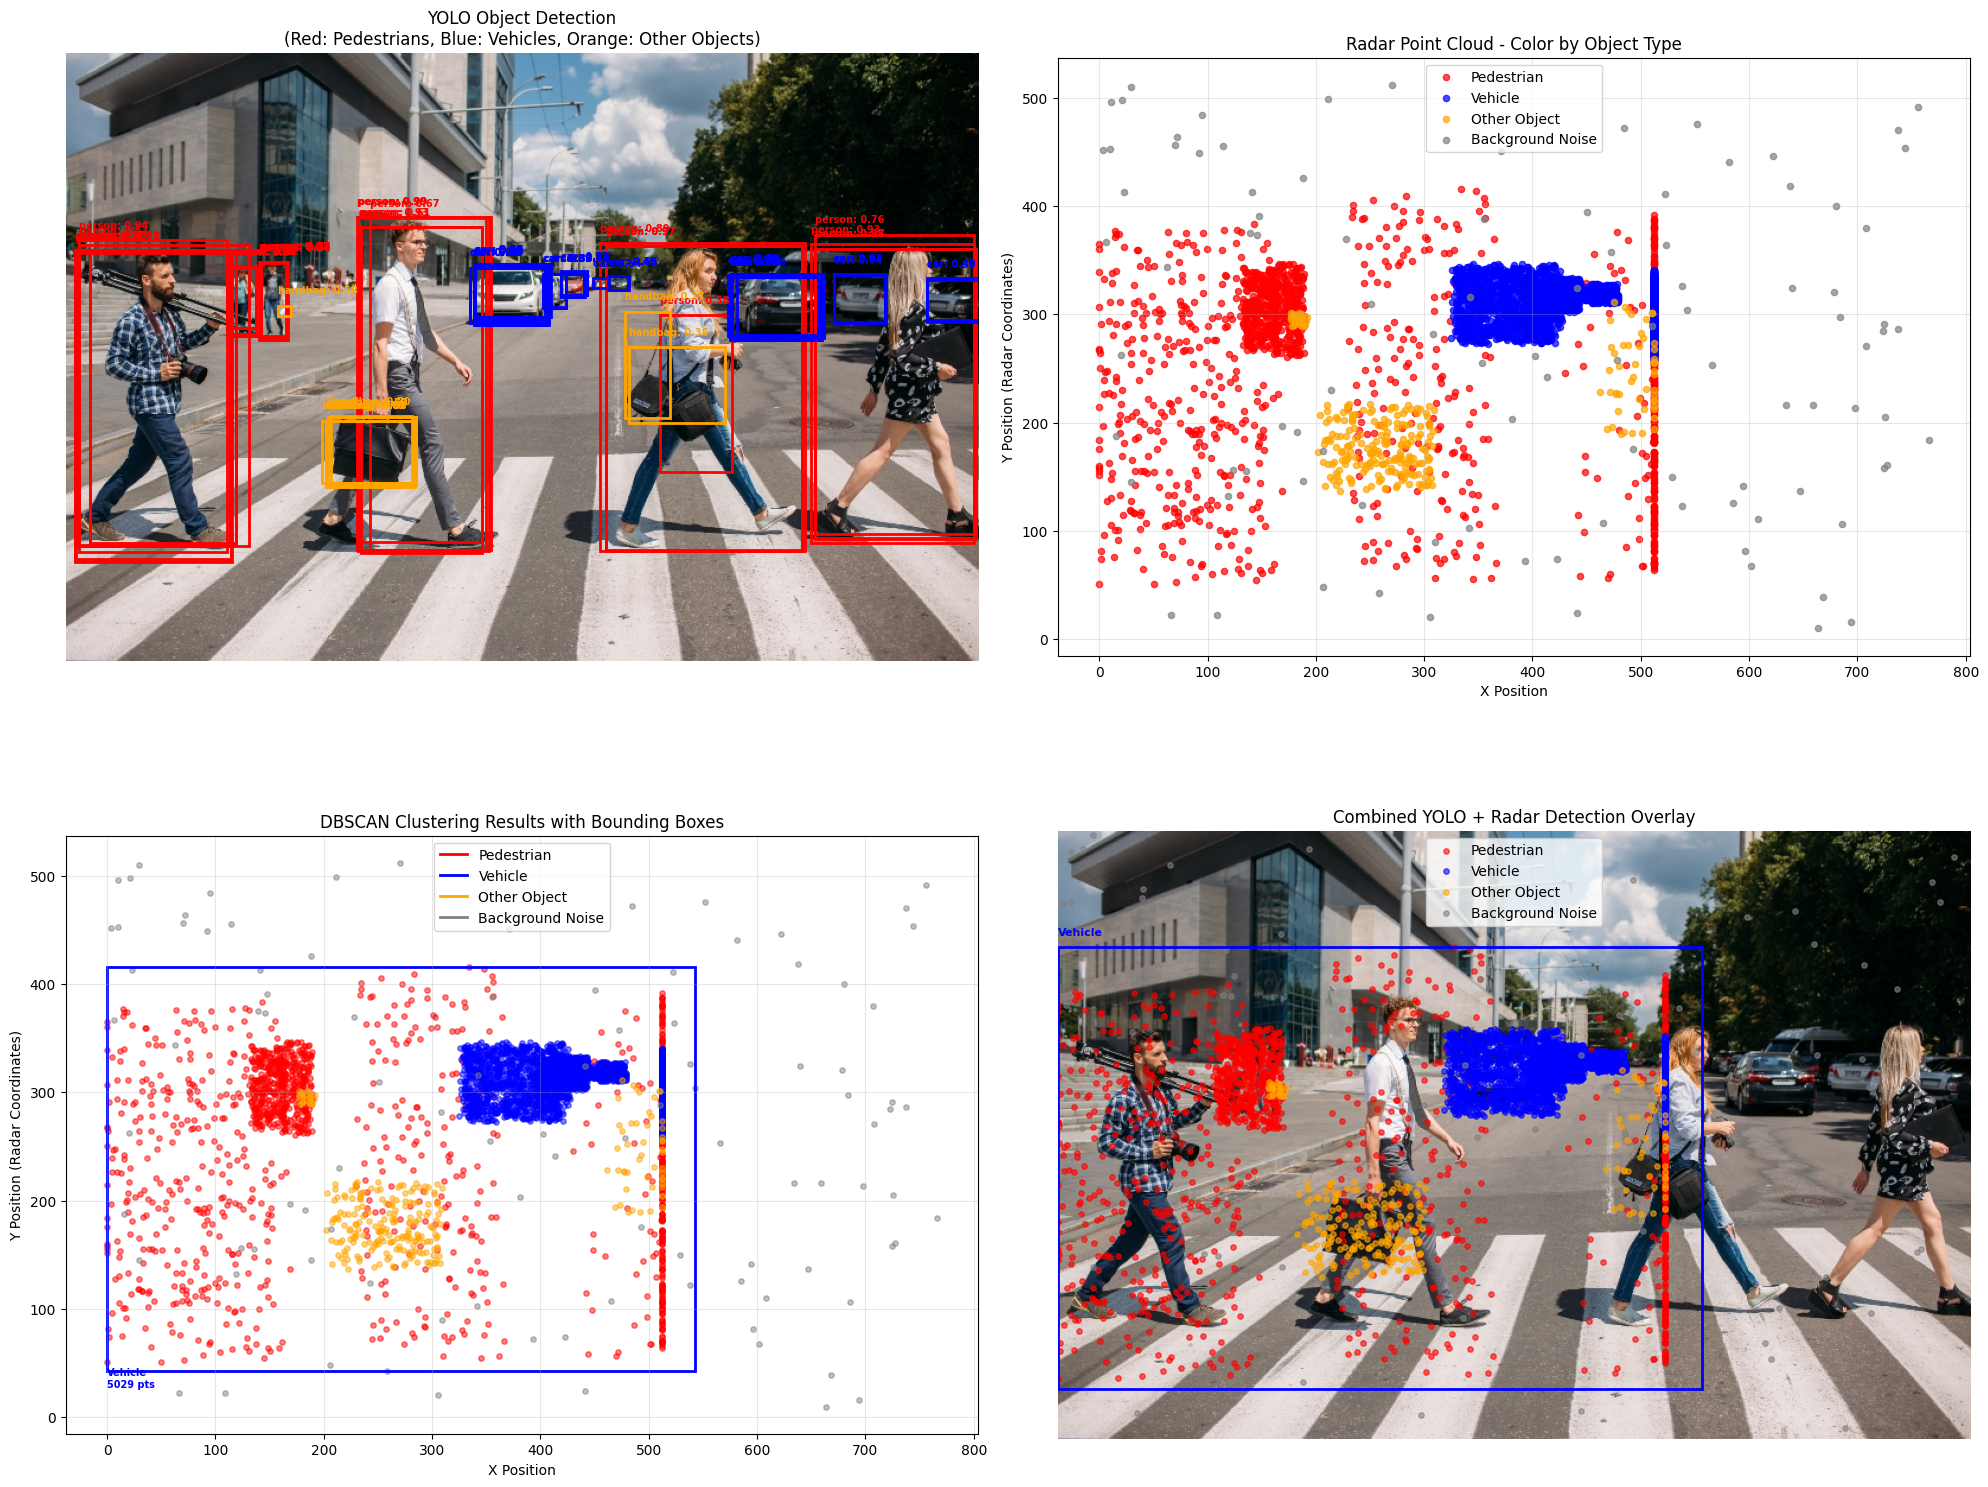

Saved results -> out/comprehensive_radar_detection.jpg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import cv2
from pathlib import Path
import requests

# ===== First, use YOLO to find all objects =====
def download(url: str, dest: str):
    p = Path(dest); p.parent.mkdir(parents=True, exist_ok=True)
    if not p.exists():
        r = requests.get(url, stream=True); r.raise_for_status()
        with open(p, "wb") as f:
            for ch in r.iter_content(1<<20):
                if ch: f.write(ch)
    return str(p)

# COCO class names
COCO = ['person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light',
        'fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant','bear',
        'zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
        'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass','cup',
        'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
        'cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard',
        'cell phone','microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
        'hair drier','toothbrush']

def detect_objects_yolo(image_path):
    """Detect all objects using YOLOv4 and categorize them"""
    # Download model files
    cfg = download("https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg", "weights/yolov4.cfg")
    wts = download("https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4.weights", "weights/yolov4.weights")

    # Load YOLO network
    net = cv2.dnn.readNetFromDarknet(cfg, wts)
    img = cv2.imread(image_path)
    H, W = img.shape[:2]

    # Preprocess and run detection
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (608,608), swapRB=True, crop=False)
    net.setInput(blob)
    outs = net.forward(net.getUnconnectedOutLayersNames())

    # Parse detections for all objects
    pedestrian_boxes = []
    vehicle_boxes = []
    other_boxes = []

    for out in outs:
        for det in out:
            confs = det[5:]
            cid = int(np.argmax(confs))
            score = float(det[4] * confs[cid])

            if score >= 0.25:
                cx, cy, bw, bh = det[0]*W, det[1]*H, det[2]*W, det[3]*H
                x1, y1 = int(cx - bw/2), int(cy - bh/2)
                x2, y2 = int(x1 + bw), int(y1 + bh)

                detection_info = (x1, y1, x2, y2, score, cid, COCO[cid])

                # Categorize detections
                if cid == 0:  # person
                    pedestrian_boxes.append(detection_info)
                elif cid in [1, 2, 3, 5, 6, 7]:  # vehicles: bicycle, car, motorcycle, bus, train, truck
                    vehicle_boxes.append(detection_info)
                else:  # other objects
                    other_boxes.append(detection_info)

    return pedestrian_boxes, vehicle_boxes, other_boxes, img

# ===== Simulate radar for different object types =====
def simulate_radar_for_objects(image_path, pedestrian_boxes, vehicle_boxes, other_boxes):
    """
    Simulate radar points for different object categories with different characteristics
    """
    img = cv2.imread(image_path)
    height, width = img.shape[:2]

    all_radar_points = []
    point_categories = []  # 0: pedestrian, 1: vehicle, 2: other, 3: background noise
    clusters_info = []

    # Radar simulation parameters for different object types
    params = {
        'pedestrian': {'points': 40, 'spread': 0.3, 'height_range': (1.0, 2.0), 'color': 'red'},
        'vehicle': {'points': 80, 'spread': 0.5, 'height_range': (0.5, 1.5), 'color': 'blue'},
        'other': {'points': 25, 'spread': 0.4, 'height_range': (0.2, 3.0), 'color': 'orange'},
        'noise': {'points': 100, 'spread': 2.0, 'height_range': (0.1, 5.0), 'color': 'gray'}
    }

    # Generate radar points for pedestrians
    for i, (x1, y1, x2, y2, score, cid, name) in enumerate(pedestrian_boxes):
        points = generate_object_radar_points(x1, y1, x2, y2, height, params['pedestrian'])
        all_radar_points.extend(points)
        point_categories.extend([0] * len(points))

        clusters_info.append({
            'type': 'pedestrian',
            'id': i,
            'center': [np.mean([p[0] for p in points]), np.mean([p[1] for p in points])],
            'points': np.array(points),
            'bbox': (x1, height-y2, x2, height-y1),
            'size': len(points),
            'confidence': score,
            'color': params['pedestrian']['color']
        })

    # Generate radar points for vehicles
    for i, (x1, y1, x2, y2, score, cid, name) in enumerate(vehicle_boxes):
        points = generate_object_radar_points(x1, y1, x2, y2, height, params['vehicle'])
        all_radar_points.extend(points)
        point_categories.extend([1] * len(points))

        clusters_info.append({
            'type': 'vehicle',
            'id': i,
            'name': name,
            'center': [np.mean([p[0] for p in points]), np.mean([p[1] for p in points])],
            'points': np.array(points),
            'bbox': (x1, height-y2, x2, height-y1),
            'size': len(points),
            'confidence': score,
            'color': params['vehicle']['color']
        })

    # Generate radar points for other objects
    for i, (x1, y1, x2, y2, score, cid, name) in enumerate(other_boxes):
        points = generate_object_radar_points(x1, y1, x2, y2, height, params['other'])
        all_radar_points.extend(points)
        point_categories.extend([2] * len(points))

        clusters_info.append({
            'type': 'other',
            'id': i,
            'name': name,
            'center': [np.mean([p[0] for p in points]), np.mean([p[1] for p in points])],
            'points': np.array(points),
            'bbox': (x1, height-y2, x2, height-y1),
            'size': len(points),
            'confidence': score,
            'color': params['other']['color']
        })

    # Generate background noise (random points throughout the scene)
    noise_points = generate_background_noise(height, width, params['noise'])
    all_radar_points.extend(noise_points)
    point_categories.extend([3] * len(noise_points))

    clusters_info.append({
        'type': 'background_noise',
        'points': np.array(noise_points),
        'size': len(noise_points),
        'color': params['noise']['color']
    })

    return np.array(all_radar_points), np.array(point_categories), clusters_info

def generate_object_radar_points(x1, y1, x2, y2, img_height, params):
    """Generate radar points for a specific object"""
    points = []
    obj_width = x2 - x1
    obj_height = y2 - y1

    for _ in range(params['points']):
        # Add spread around the object
        spread_x = obj_width * params['spread']
        spread_y = obj_height * params['spread']

        x = np.random.uniform(x1 - spread_x/2, x2 + spread_x/2)
        y = np.random.uniform(y1 - spread_y/2, y2 + spread_y/2)

        # Ensure points are within image bounds
        x = np.clip(x, 0, img_height-1)
        y = np.clip(y, 0, img_height-1)

        # Convert to radar coordinates
        radar_y = img_height - y
        z = np.random.uniform(params['height_range'][0], params['height_range'][1])

        points.append([x, radar_y, z])

    return points

def generate_background_noise(img_height, img_width, params):
    """Generate random background noise points"""
    noise_points = []

    for _ in range(params['points']):
        x = np.random.uniform(0, img_width)
        y = np.random.uniform(0, img_height)
        radar_y = img_height - y
        z = np.random.uniform(params['height_range'][0], params['height_range'][1])
        noise_points.append([x, radar_y, z])

    return noise_points

def apply_dbscan_with_categories(radar_points, point_categories, eps=30, min_samples=8):
    """
    Apply DBSCAN and maintain category information
    """
    if len(radar_points) == 0:
        return [], [], []

    points_2d = radar_points[:, :2]

    # DBSCAN clustering
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = dbscan.fit_predict(points_2d)

    # Analyze clusters with category information
    refined_clusters = []
    unique_labels = set(cluster_labels)

    for label in unique_labels:
        if label == -1:  # Noise points from DBSCAN
            continue

        cluster_mask = (cluster_labels == label)
        cluster_points = points_2d[cluster_mask]
        cluster_categories = point_categories[cluster_mask]

        if len(cluster_points) >= min_samples:
            # Determine dominant category in cluster
            unique_cats, counts = np.unique(cluster_categories, return_counts=True)
            dominant_cat = unique_cats[np.argmax(counts)]

            category_names = {0: 'pedestrian', 1: 'vehicle', 2: 'other', 3: 'noise'}
            category_colors = {0: 'red', 1: 'blue', 2: 'orange', 3: 'gray'}

            min_x, min_y = np.min(cluster_points, axis=0)
            max_x, max_y = np.max(cluster_points, axis=0)

            refined_clusters.append({
                'label': label,
                'type': category_names[dominant_cat],
                'center': np.mean(cluster_points, axis=0),
                'bbox': (min_x, min_y, max_x, max_y),
                'size': len(cluster_points),
                'points': cluster_points,
                'color': category_colors[dominant_cat],
                'category_composition': dict(zip(unique_cats, counts))
            })

    return cluster_labels, refined_clusters, point_categories

# ===== Visualization =====
def visualize_complete_radar_detection(original_img, radar_points, point_categories, clusters_info, refined_clusters, yolo_detections):
    """
    Visualize complete radar detection with different colors for each object type
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

    # Color mapping
    category_colors = {
        0: 'red',      # pedestrians
        1: 'blue',     # vehicles
        2: 'orange',   # other objects
        3: 'gray'      # background noise
    }

    category_labels = {
        0: 'Pedestrian',
        1: 'Vehicle',
        2: 'Other Object',
        3: 'Background Noise'
    }

    # Plot 1: Original image with YOLO detections (color-coded)
    img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    ax1.imshow(img_rgb)

    # Draw bounding boxes with different colors
    for category_boxes, color in zip(yolo_detections, ['red', 'blue', 'orange']):
        for x1, y1, x2, y2, score, cid, name in category_boxes:
            ax1.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                      fill=False, edgecolor=color, linewidth=2))
            ax1.text(x1, y1-10, f'{name}: {score:.2f}',
                    color=color, weight='bold', fontsize=7)

    ax1.set_title('YOLO Object Detection\n(Red: Pedestrians, Blue: Vehicles, Orange: Other Objects)')
    ax1.axis('off')

    # Plot 2: Raw radar point cloud (color by category)
    if len(radar_points) > 0:
        for category in [0, 1, 2, 3]:
            mask = (point_categories == category)
            if np.any(mask):
                category_points = radar_points[mask]
                ax2.scatter(category_points[:, 0], category_points[:, 1],
                           c=category_colors[category], s=20, alpha=0.7,
                           label=category_labels[category])

    ax2.set_xlabel('X Position')
    ax2.set_ylabel('Y Position (Radar Coordinates)')
    ax2.set_title('Radar Point Cloud - Color by Object Type')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_aspect('equal')

    # Plot 3: DBSCAN clustering results
    if len(radar_points) > 0:
        # Plot all points first
        for category in [0, 1, 2, 3]:
            mask = (point_categories == category)
            if np.any(mask):
                category_points = radar_points[mask]
                ax3.scatter(category_points[:, 0], category_points[:, 1],
                           c=category_colors[category], s=15, alpha=0.5)

        # Draw DBSCAN cluster bounding boxes
        for cluster in refined_clusters:
            bbox = cluster['bbox']
            min_x, min_y, max_x, max_y = bbox

            rect = plt.Rectangle((min_x, min_y), max_x-min_x, max_y-min_y,
                               fill=False, edgecolor=cluster['color'], linewidth=2)
            ax3.add_patch(rect)

            ax3.scatter(cluster['center'][0], cluster['center'][1],
                       c=cluster['color'], marker='x', s=100, linewidths=2)

            ax3.text(min_x, min_y-15, f'{cluster["type"].title()}\n{cluster["size"]} pts',
                    fontsize=7, color=cluster['color'], weight='bold')

    ax3.set_xlabel('X Position')
    ax3.set_ylabel('Y Position (Radar Coordinates)')
    ax3.set_title('DBSCAN Clustering Results with Bounding Boxes')
    ax3.grid(True, alpha=0.3)
    ax3.legend([plt.Line2D([0], [0], color=color, lw=2) for color in category_colors.values()],
               category_labels.values())
    ax3.set_aspect('equal')

    # Plot 4: Combined overlay on image
    ax4.imshow(img_rgb)
    height = original_img.shape[0]

    # Overlay radar points (convert back to image coordinates)
    if len(radar_points) > 0:
        for category in [0, 1, 2, 3]:
            mask = (point_categories == category)
            if np.any(mask):
                category_points = radar_points[mask]
                img_y = height - category_points[:, 1]  # Convert back to image coordinates
                ax4.scatter(category_points[:, 0], img_y,
                           c=category_colors[category], s=15, alpha=0.6,
                           label=category_labels[category])

    # Overlay DBSCAN clusters
    for cluster in refined_clusters:
        bbox = cluster['bbox']
        min_x, min_y, max_x, max_y = bbox

        # Convert back to image coordinates
        img_min_y = height - max_y
        img_max_y = height - min_y

        rect = plt.Rectangle((min_x, img_min_y), max_x-min_x, img_max_y-img_min_y,
                           fill=False, edgecolor=cluster['color'], linewidth=2)
        ax4.add_patch(rect)

        center_img_y = height - cluster['center'][1]
        ax4.scatter(cluster['center'][0], center_img_y,
                   c=cluster['color'], marker='x', s=100, linewidths=2)

        ax4.text(min_x, img_min_y-10, f'{cluster["type"].title()}',
                fontsize=8, color=cluster['color'], weight='bold')

    ax4.set_title('Combined YOLO + Radar Detection Overlay')
    ax4.axis('off')
    ax4.legend()

    plt.tight_layout()
    plt.show()

    return fig

def print_detailed_results(pedestrian_boxes, vehicle_boxes, other_boxes, refined_clusters):
    """Print detailed detection results"""
    print(f"\n=== YOLO DETECTION RESULTS ===")
    print(f"Pedestrians detected: {len(pedestrian_boxes)}")
    print(f"Vehicles detected: {len(vehicle_boxes)}")
    print(f"Other objects detected: {len(other_boxes)}")

    print(f"\n=== RADAR CLUSTERING RESULTS ===")
    print(f"Total DBSCAN clusters: {len(refined_clusters)}")

    # Count clusters by type
    type_counts = {}
    for cluster in refined_clusters:
        cluster_type = cluster['type']
        type_counts[cluster_type] = type_counts.get(cluster_type, 0) + 1

    for obj_type, count in type_counts.items():
        print(f"{obj_type.title()} clusters: {count}")

    print(f"\n=== CLUSTER DETAILS ===")
    for i, cluster in enumerate(refined_clusters):
        print(f"Cluster {i+1}: {cluster['type'].title()}")
        print(f"  - Center: ({cluster['center'][0]:.1f}, {cluster['center'][1]:.1f})")
        print(f"  - Size: {cluster['size']} points")
        print(f"  - BBox: [{cluster['bbox'][0]:.1f}, {cluster['bbox'][1]:.1f}, {cluster['bbox'][2]:.1f}, {cluster['bbox'][3]:.1f}]")
        if 'category_composition' in cluster:
            comp = cluster['category_composition']
            print(f"  - Composition: {comp}")

def main():
    """Main function for complete radar-based object detection"""
    image_path = "data/pedestrian_sample.jpg"

    # Ensure image exists
    if not Path(image_path).exists():
        print("Downloading sample image...")
        Path("data").mkdir(exist_ok=True)
        download("https://callsam.com/wp-content/uploads/2019/12/crosswalk-featured.jpg", image_path)

    print("Step 1: Detecting all objects with YOLO...")
    pedestrian_boxes, vehicle_boxes, other_boxes, original_img = detect_objects_yolo(image_path)

    total_objects = len(pedestrian_boxes) + len(vehicle_boxes) + len(other_boxes)
    if total_objects == 0:
        print("No objects detected in the image!")
        return

    print(f"YOLO detected {total_objects} objects total")

    print("Step 2: Simulating radar for all object categories...")
    radar_points, point_categories, clusters_info = simulate_radar_for_objects(
        image_path, pedestrian_boxes, vehicle_boxes, other_boxes
    )

    print("Step 3: Applying DBSCAN clustering...")
    cluster_labels, refined_clusters, point_categories = apply_dbscan_with_categories(
        radar_points, point_categories
    )

    # Print detailed results
    yolo_detections = [pedestrian_boxes, vehicle_boxes, other_boxes]
    print_detailed_results(pedestrian_boxes, vehicle_boxes, other_boxes, refined_clusters)

    print("\nGenerating comprehensive visualization...")
    fig = visualize_complete_radar_detection(
        original_img, radar_points, point_categories, clusters_info, refined_clusters, yolo_detections
    )

    # Save results
    output_dir = Path("out")
    output_dir.mkdir(exist_ok=True)
    fig.savefig("out/comprehensive_radar_detection.jpg", dpi=300, bbox_inches='tight')
    print("Saved results -> out/comprehensive_radar_detection.jpg")

if __name__ == "__main__":
    main()

=== SENSOR FUSION COMPARISON: SIMPLE vs EKF ===
Processing multiple frames to show comparison...
Processing frame 1...


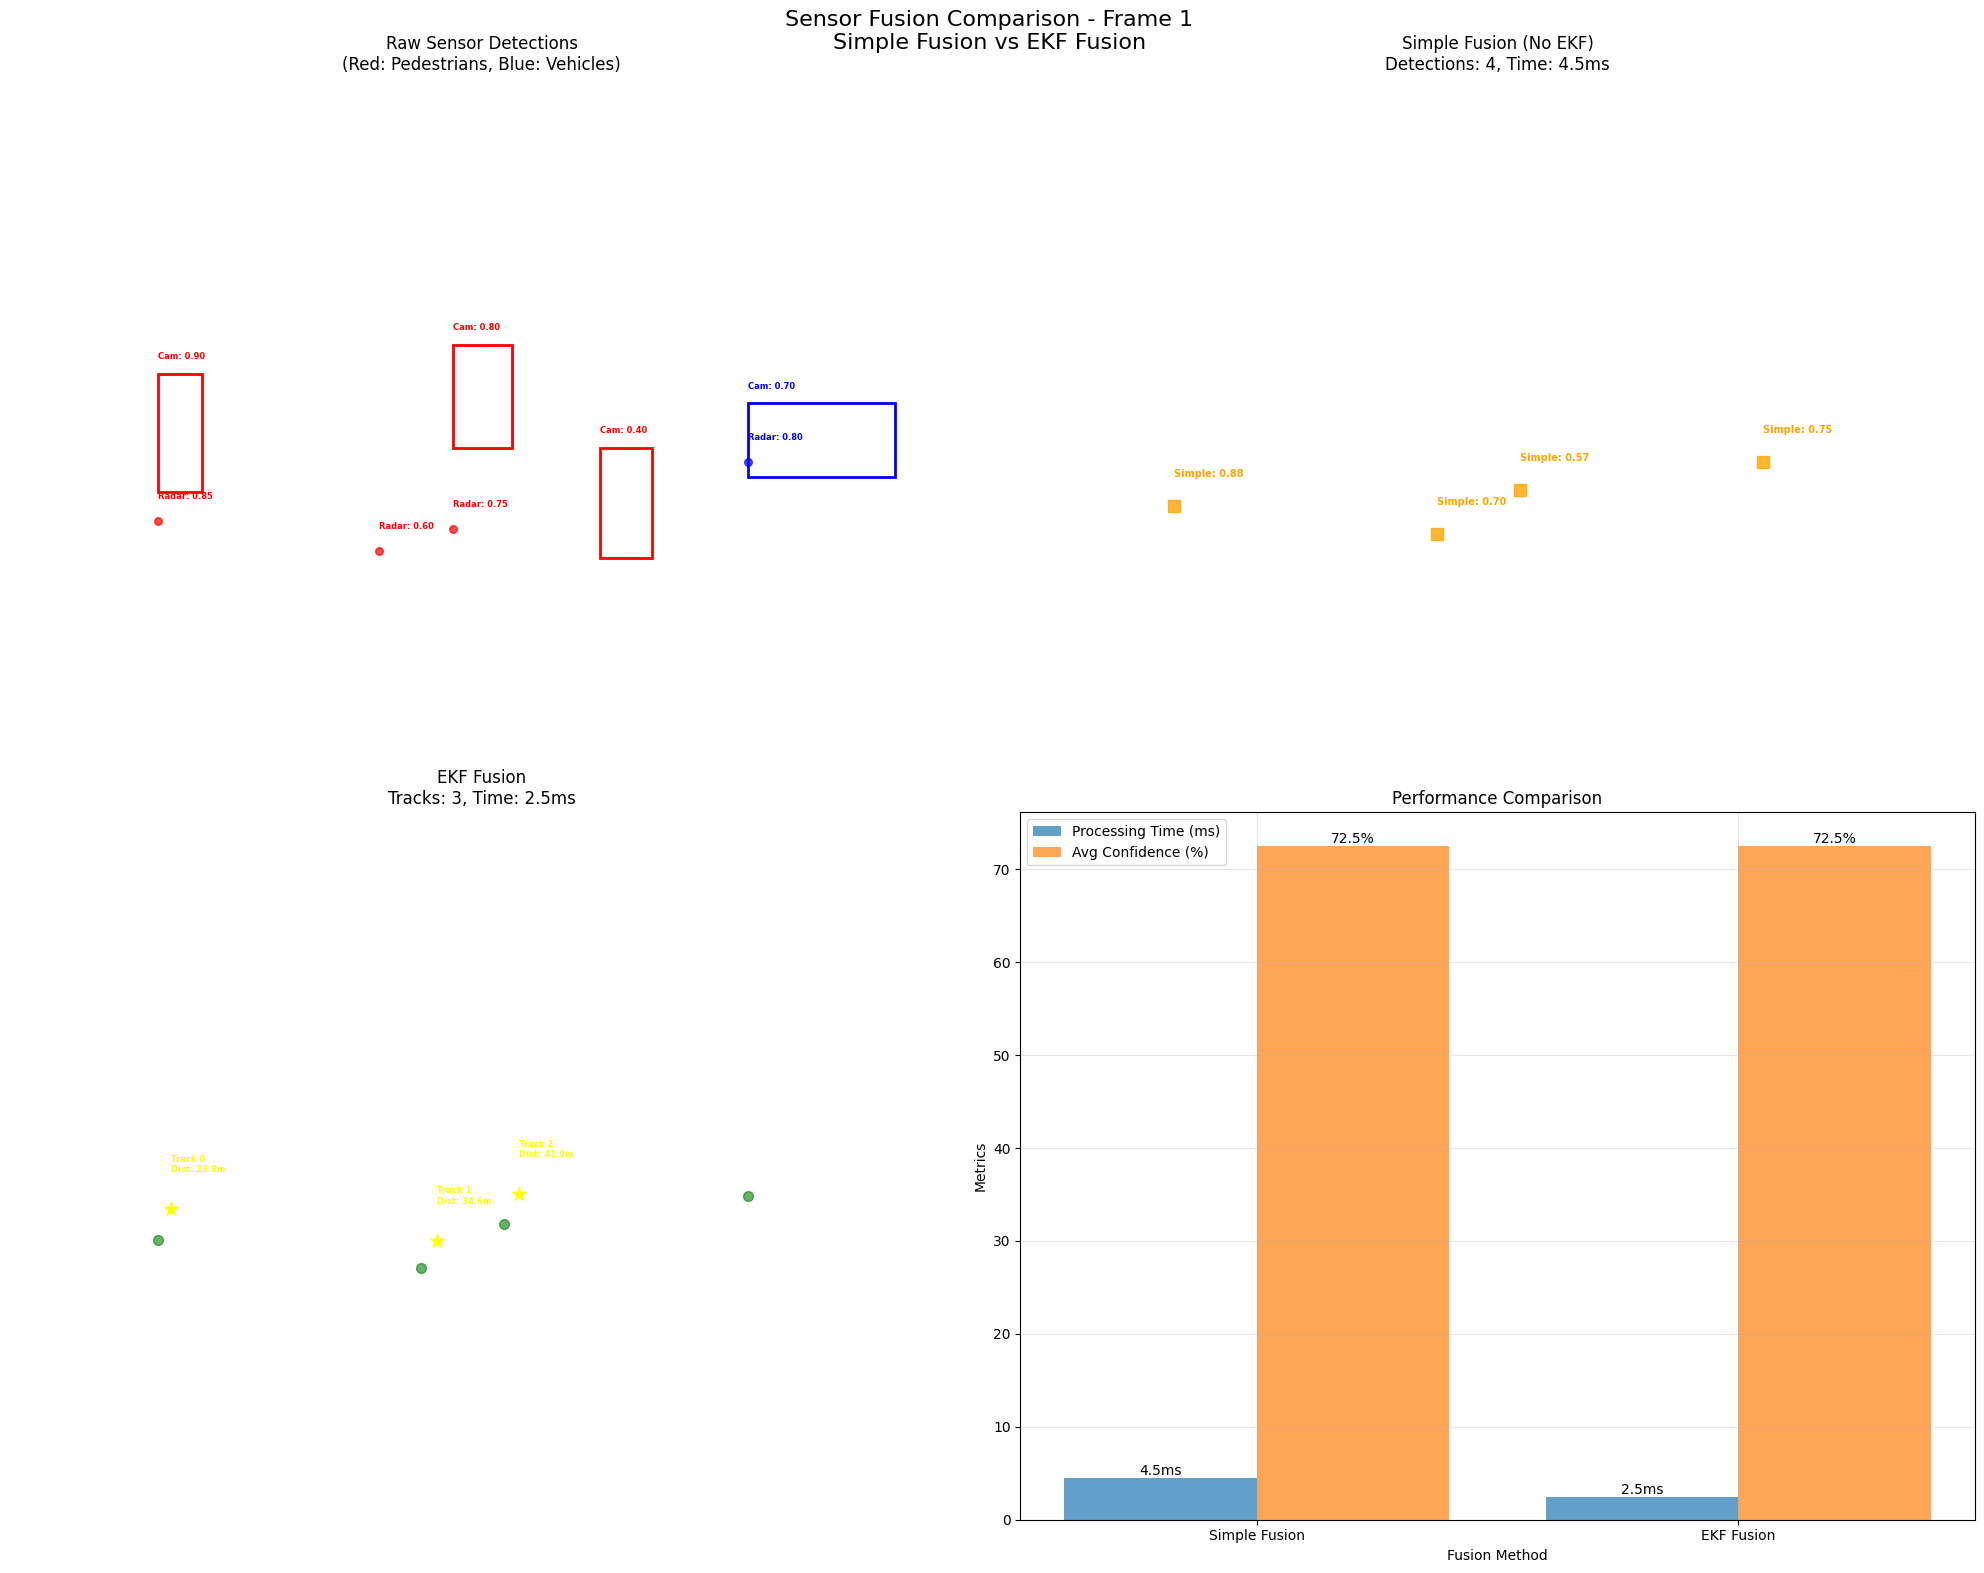

  Simple Fusion: 4 detections, 4.5ms
  EKF Fusion: 3 tracks, 2.5ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------
Processing frame 2...


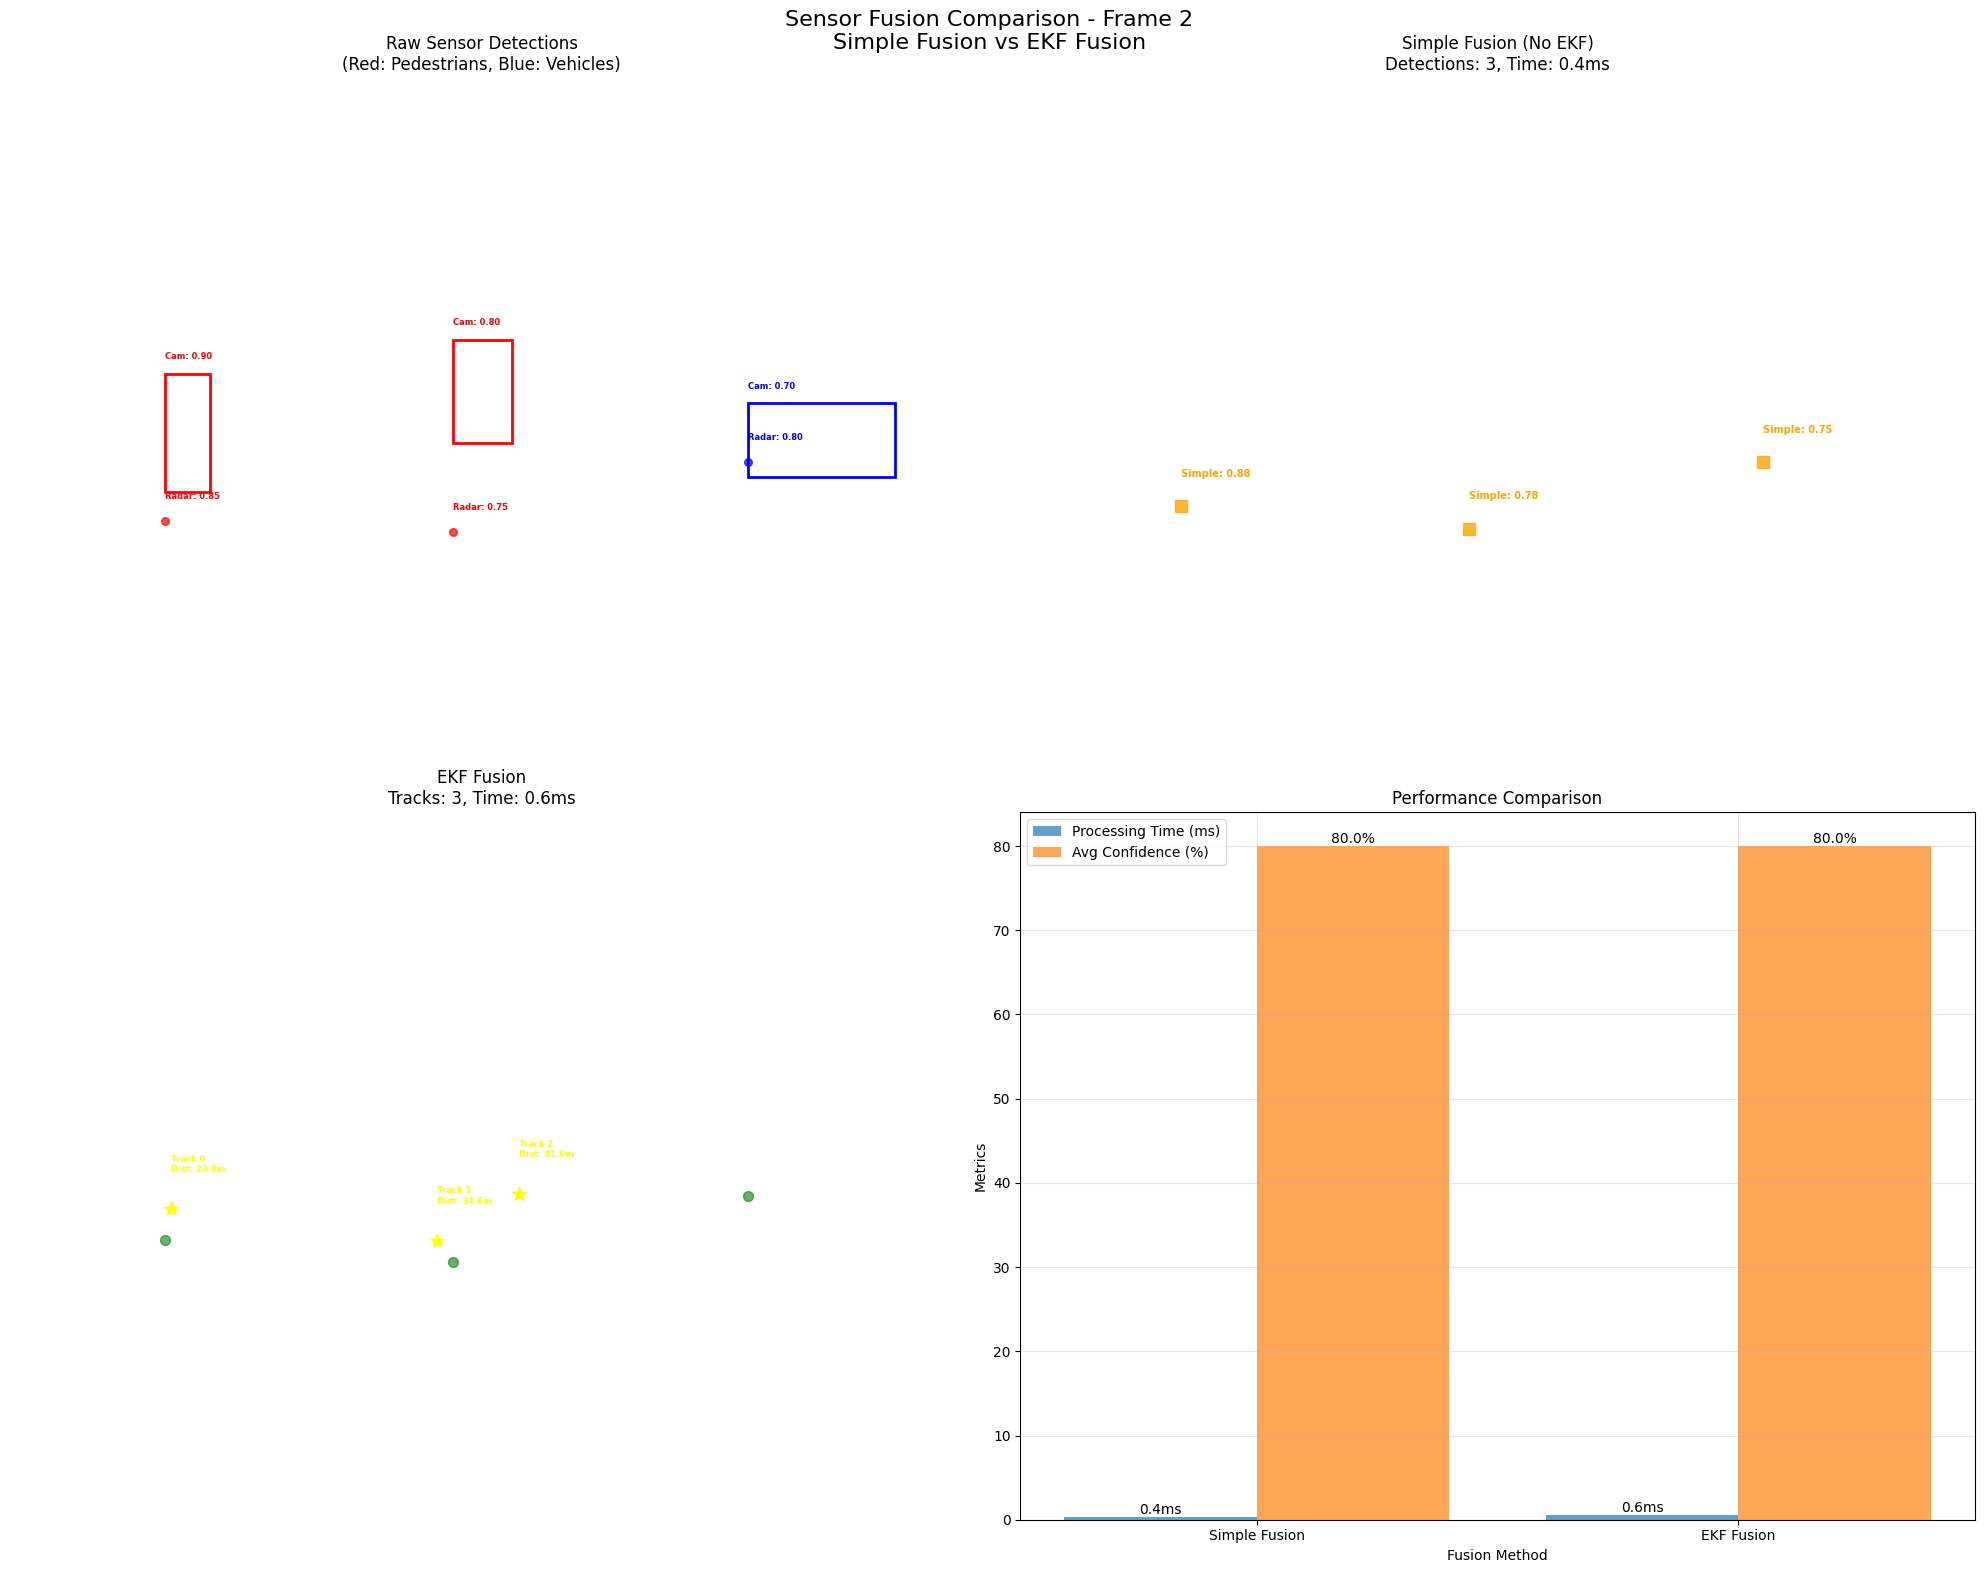

  Simple Fusion: 3 detections, 0.4ms
  EKF Fusion: 3 tracks, 0.6ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------
Processing frame 3...


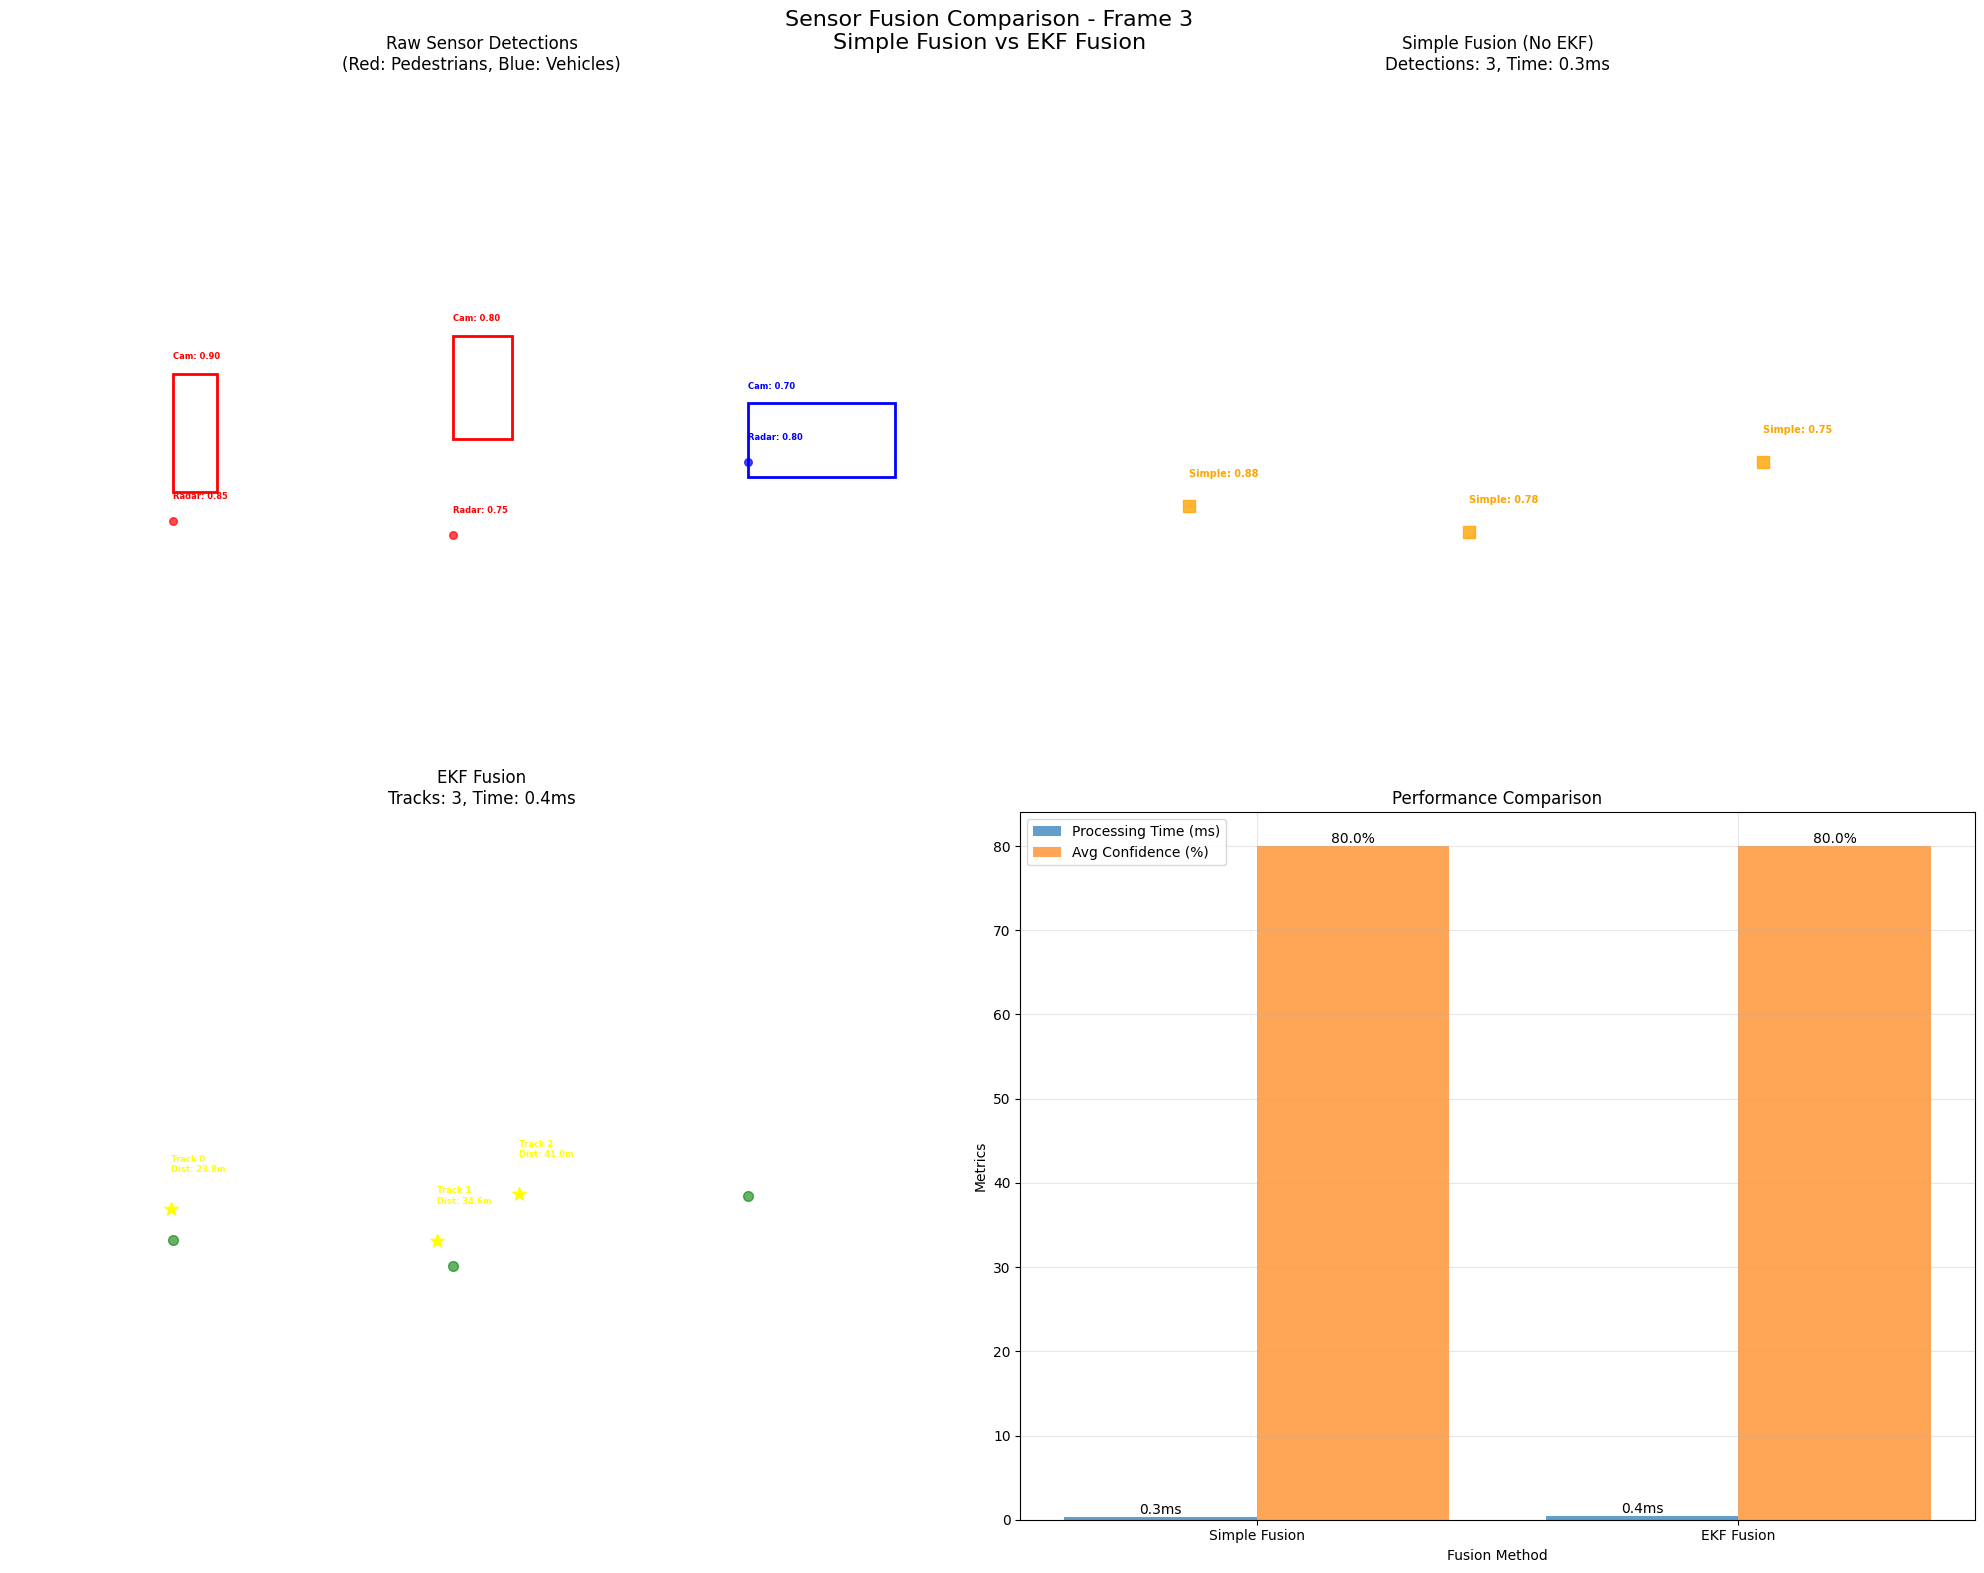

  Simple Fusion: 3 detections, 0.3ms
  EKF Fusion: 3 tracks, 0.4ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------
Processing frame 4...


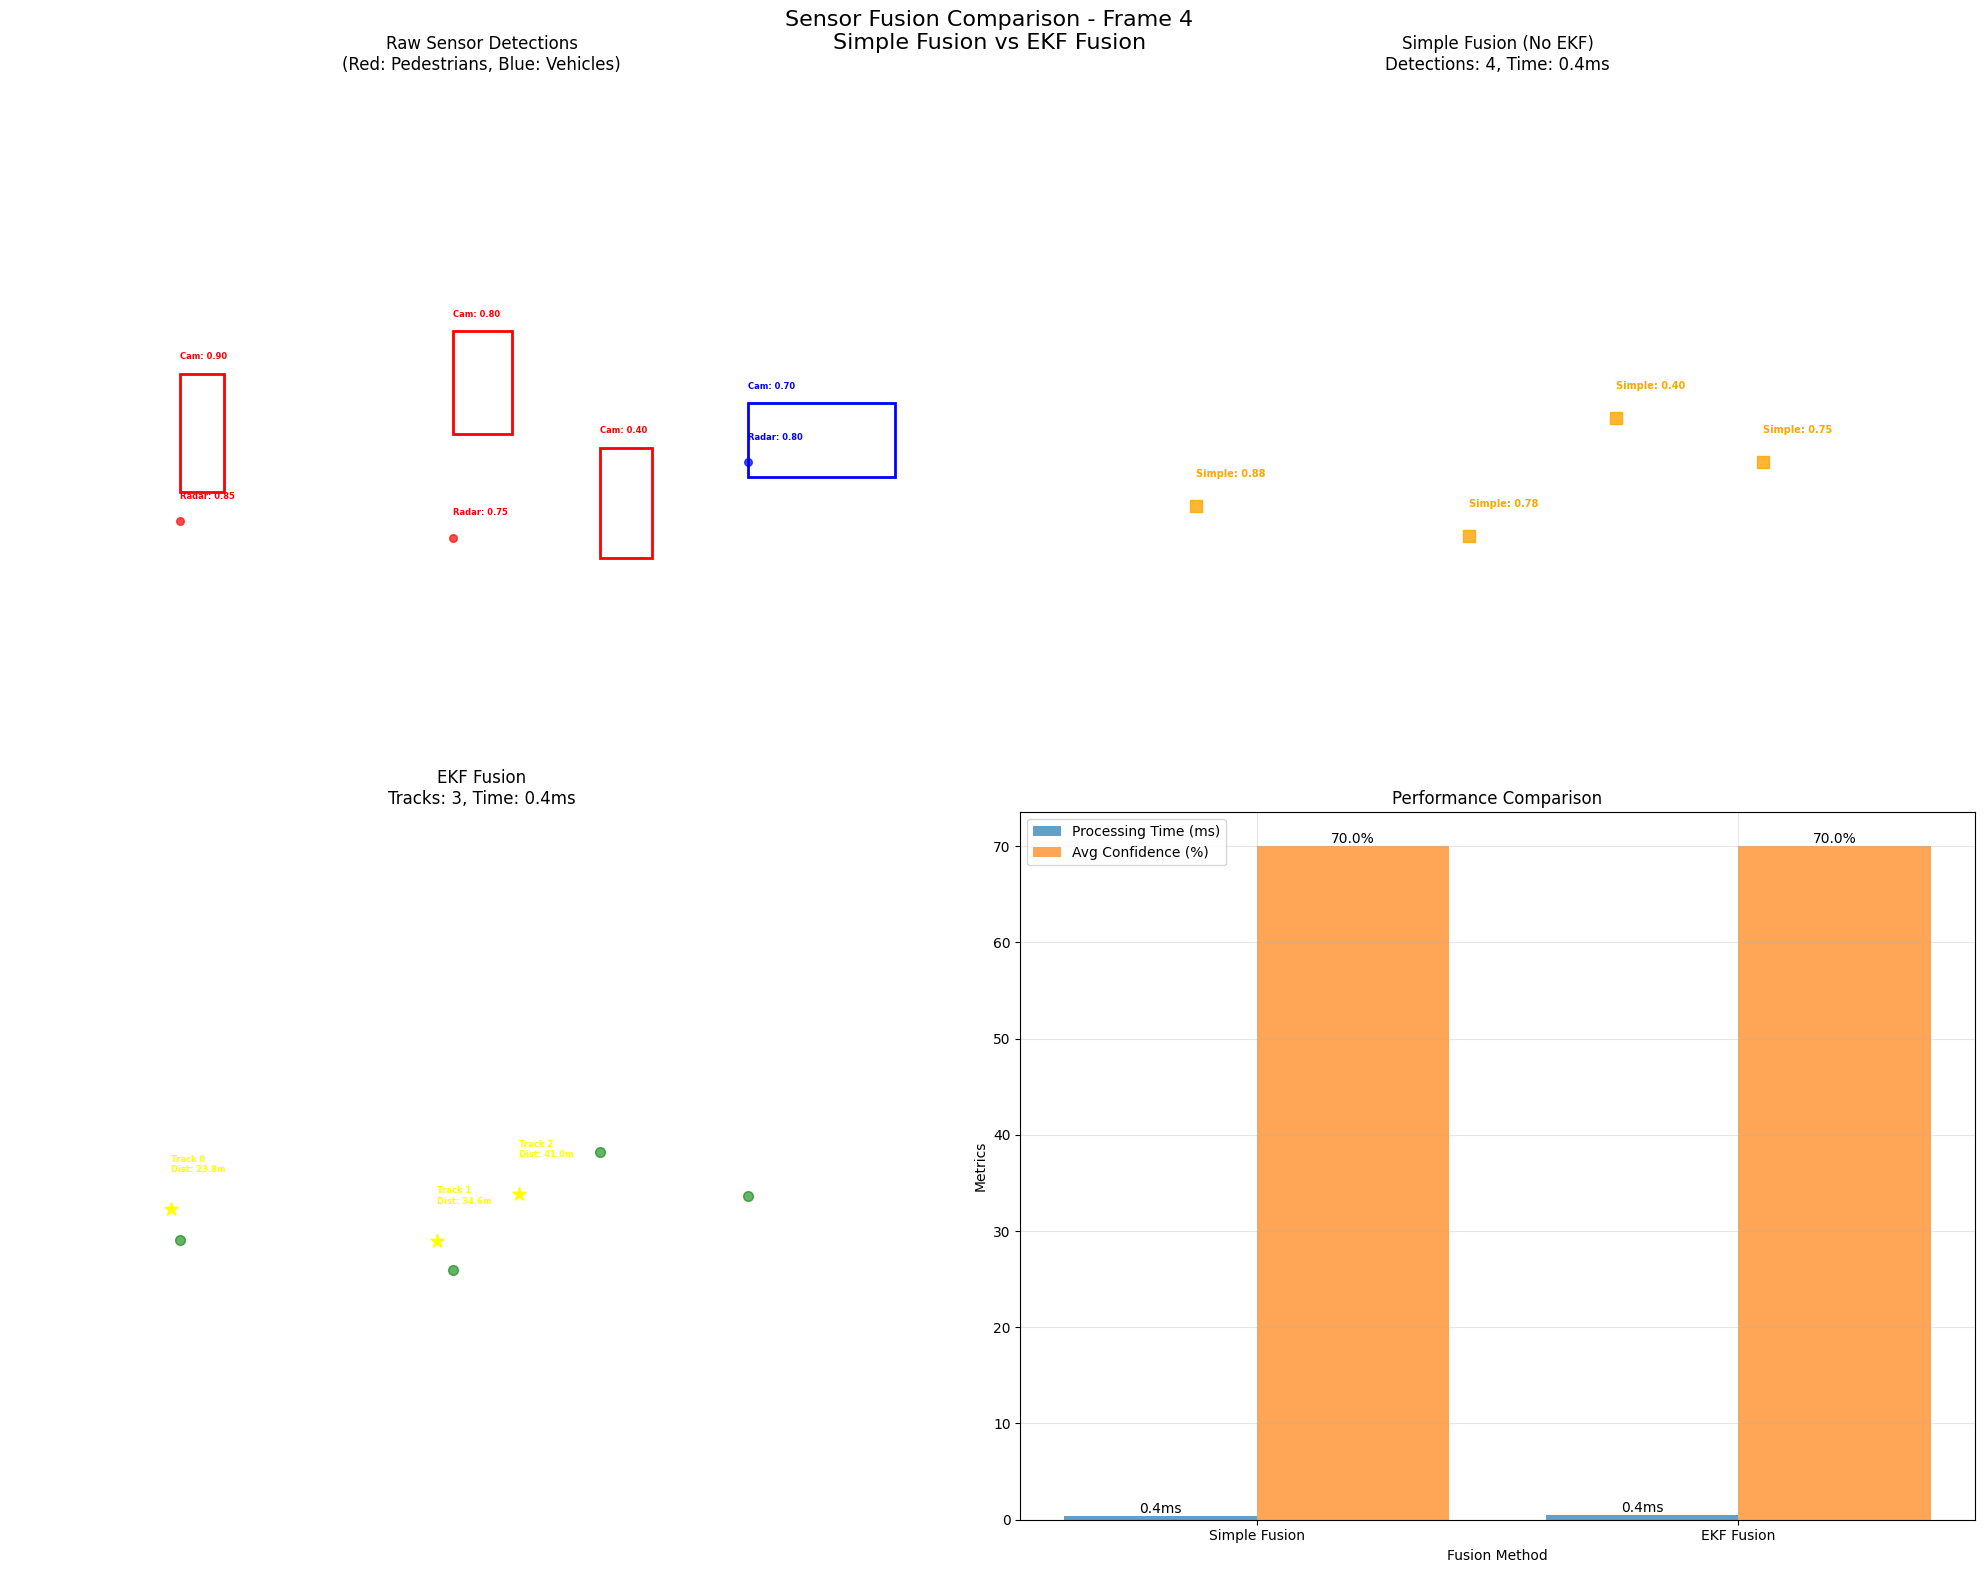

  Simple Fusion: 4 detections, 0.4ms
  EKF Fusion: 3 tracks, 0.4ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------
Processing frame 5...


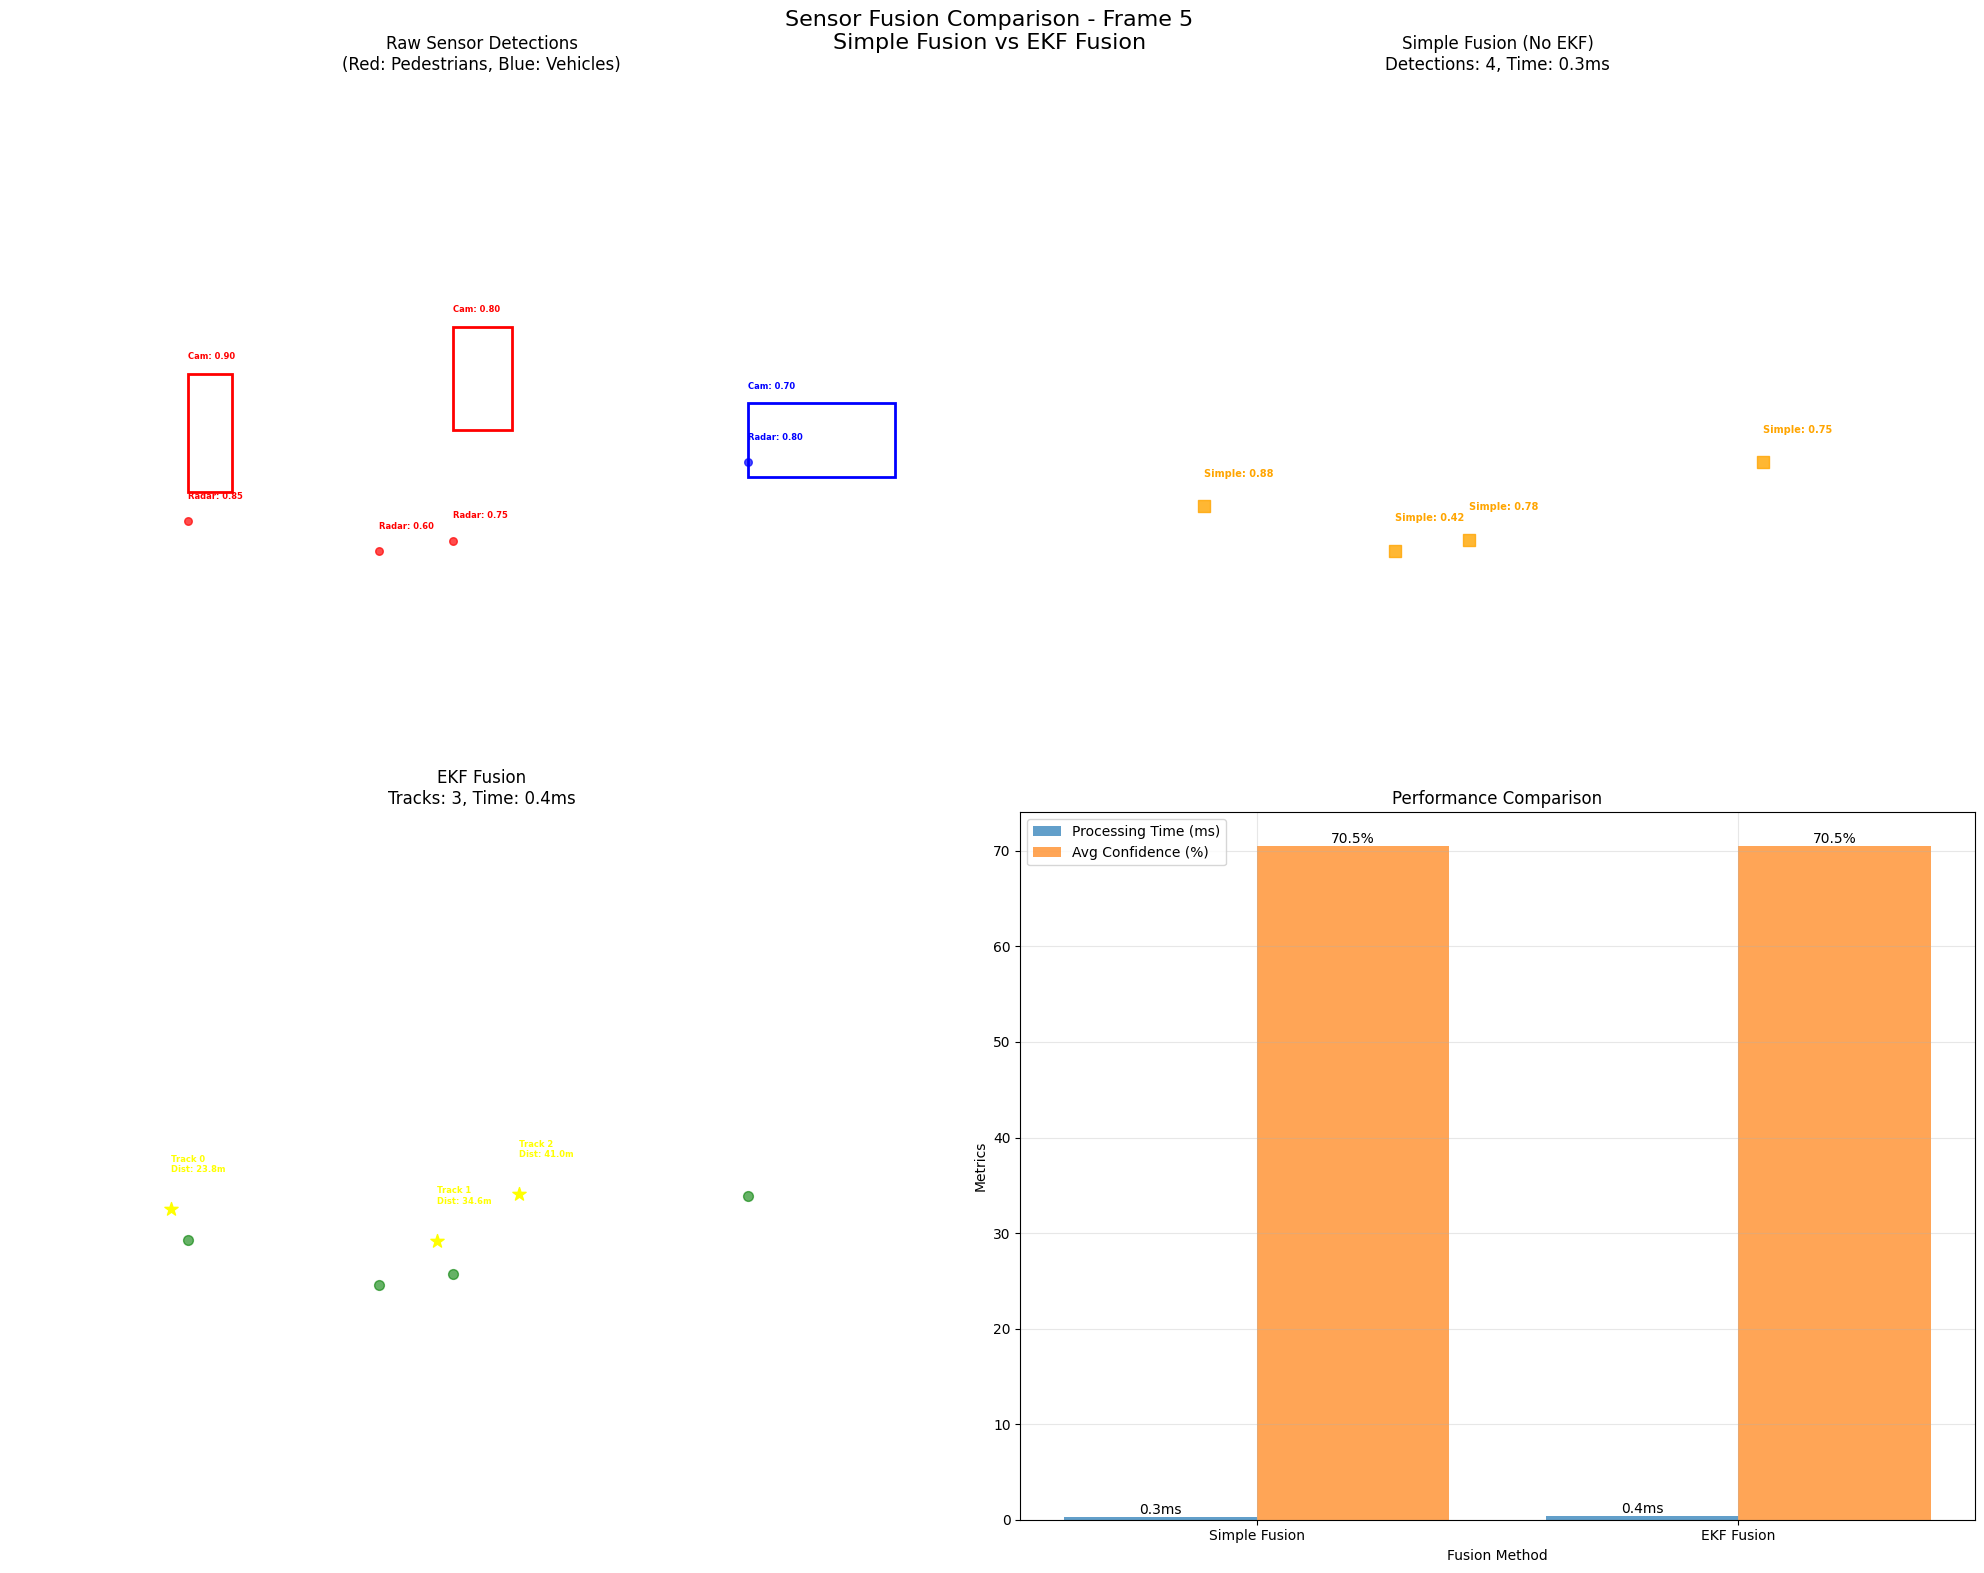

  Simple Fusion: 4 detections, 0.3ms
  EKF Fusion: 3 tracks, 0.4ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------
Processing frame 6...


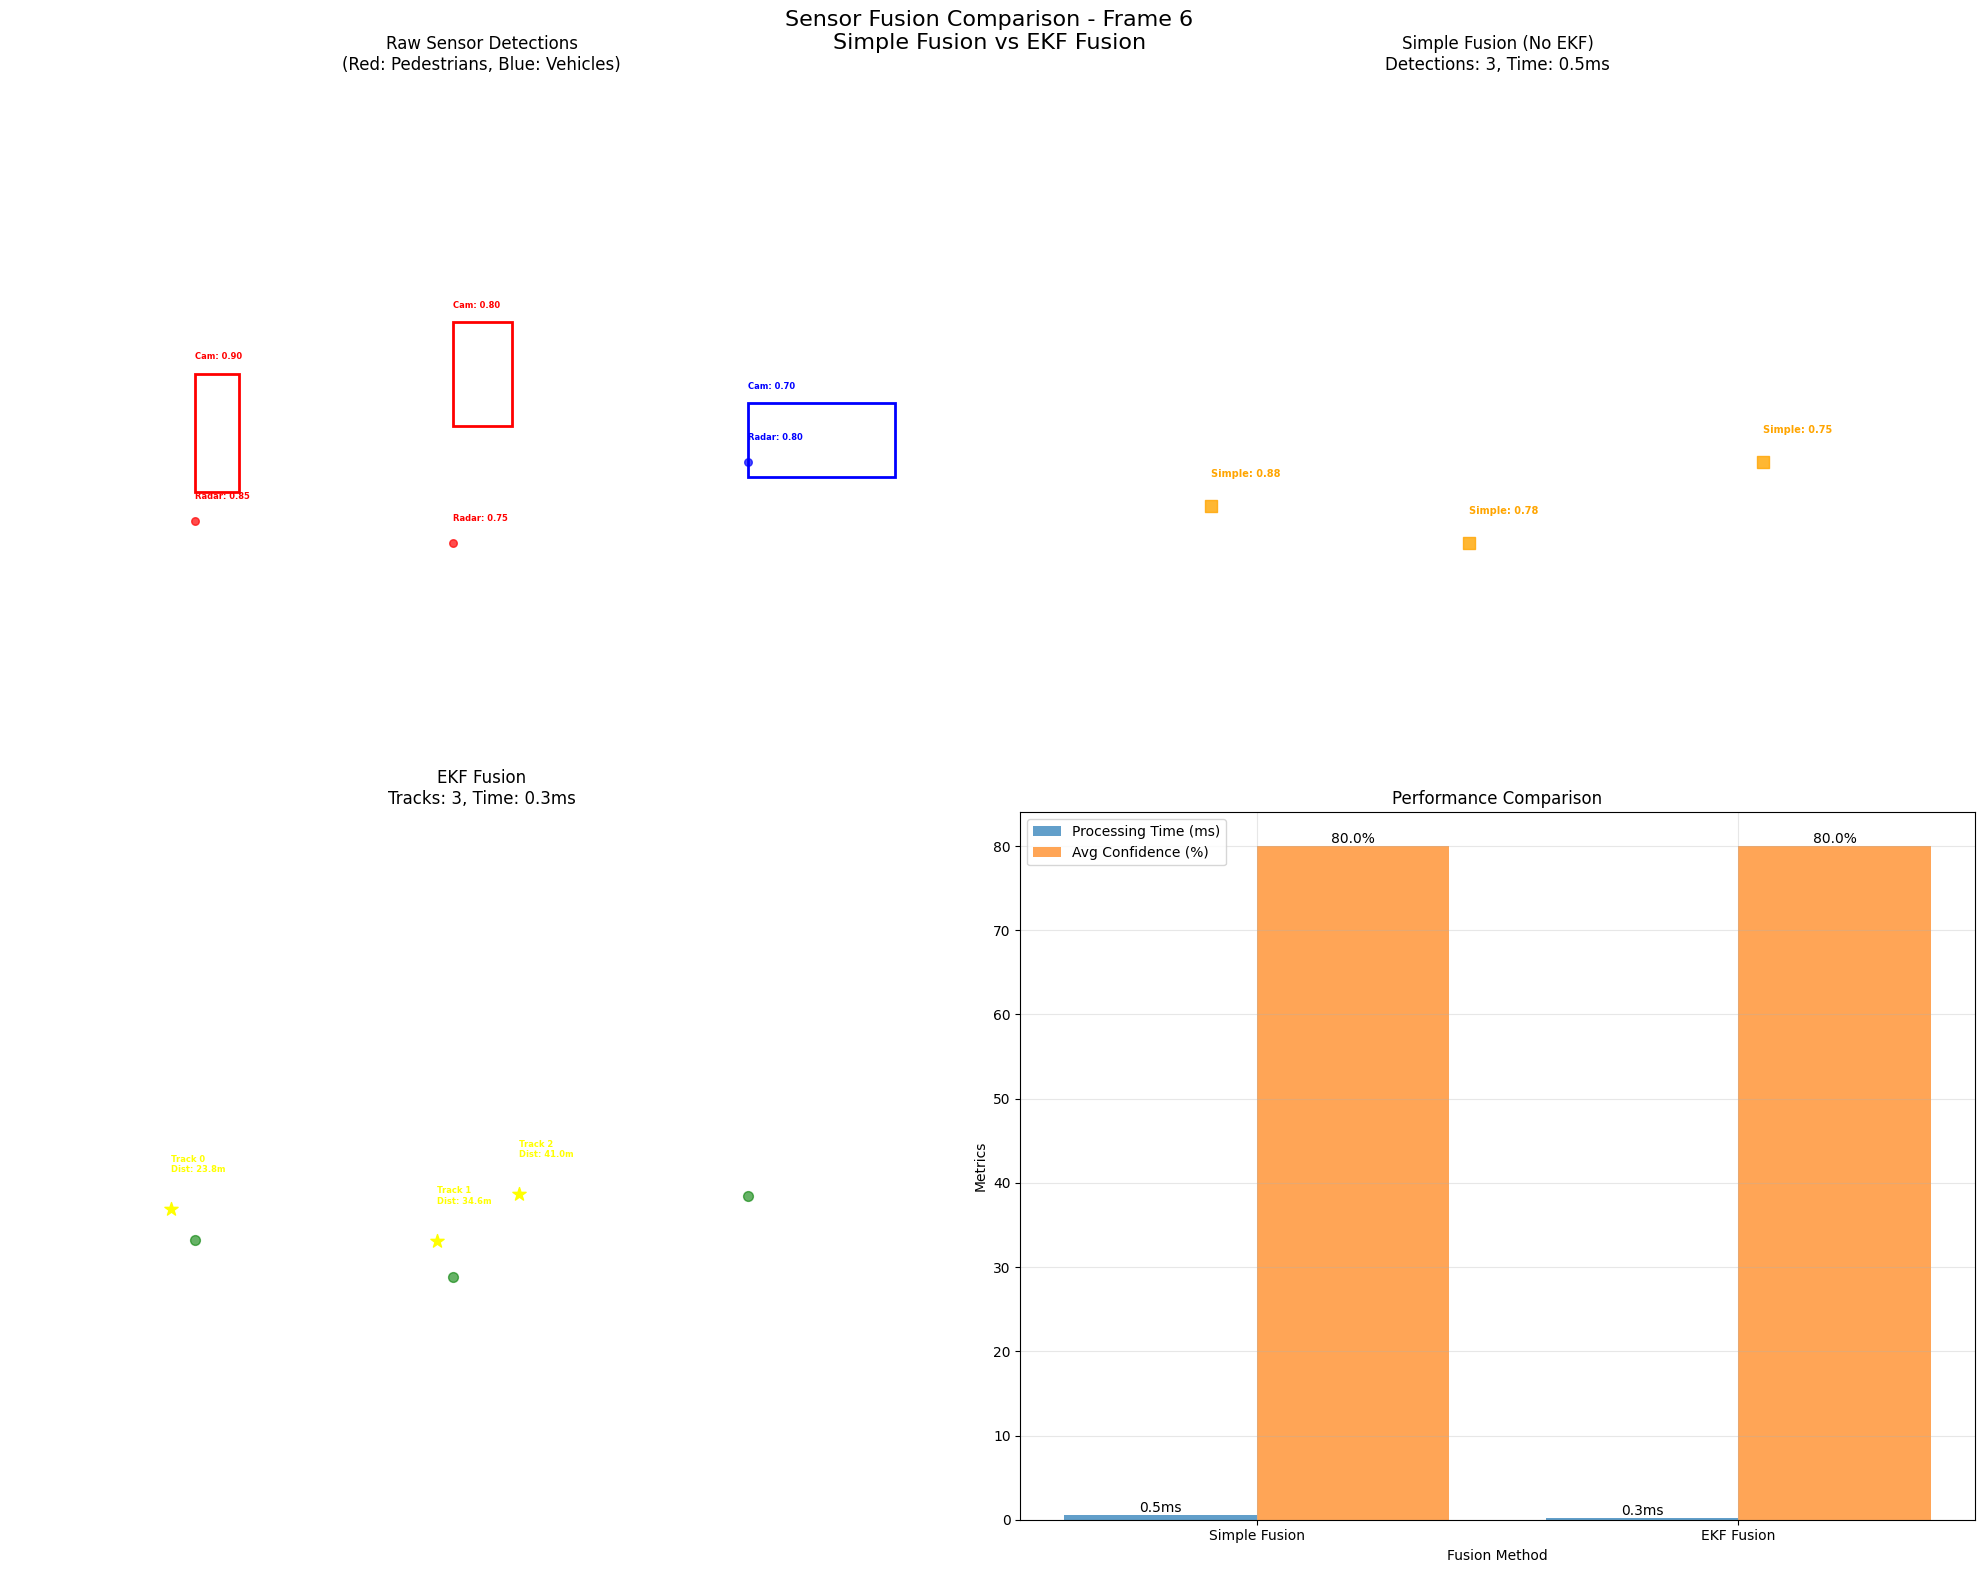

  Simple Fusion: 3 detections, 0.5ms
  EKF Fusion: 3 tracks, 0.3ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------
Processing frame 7...


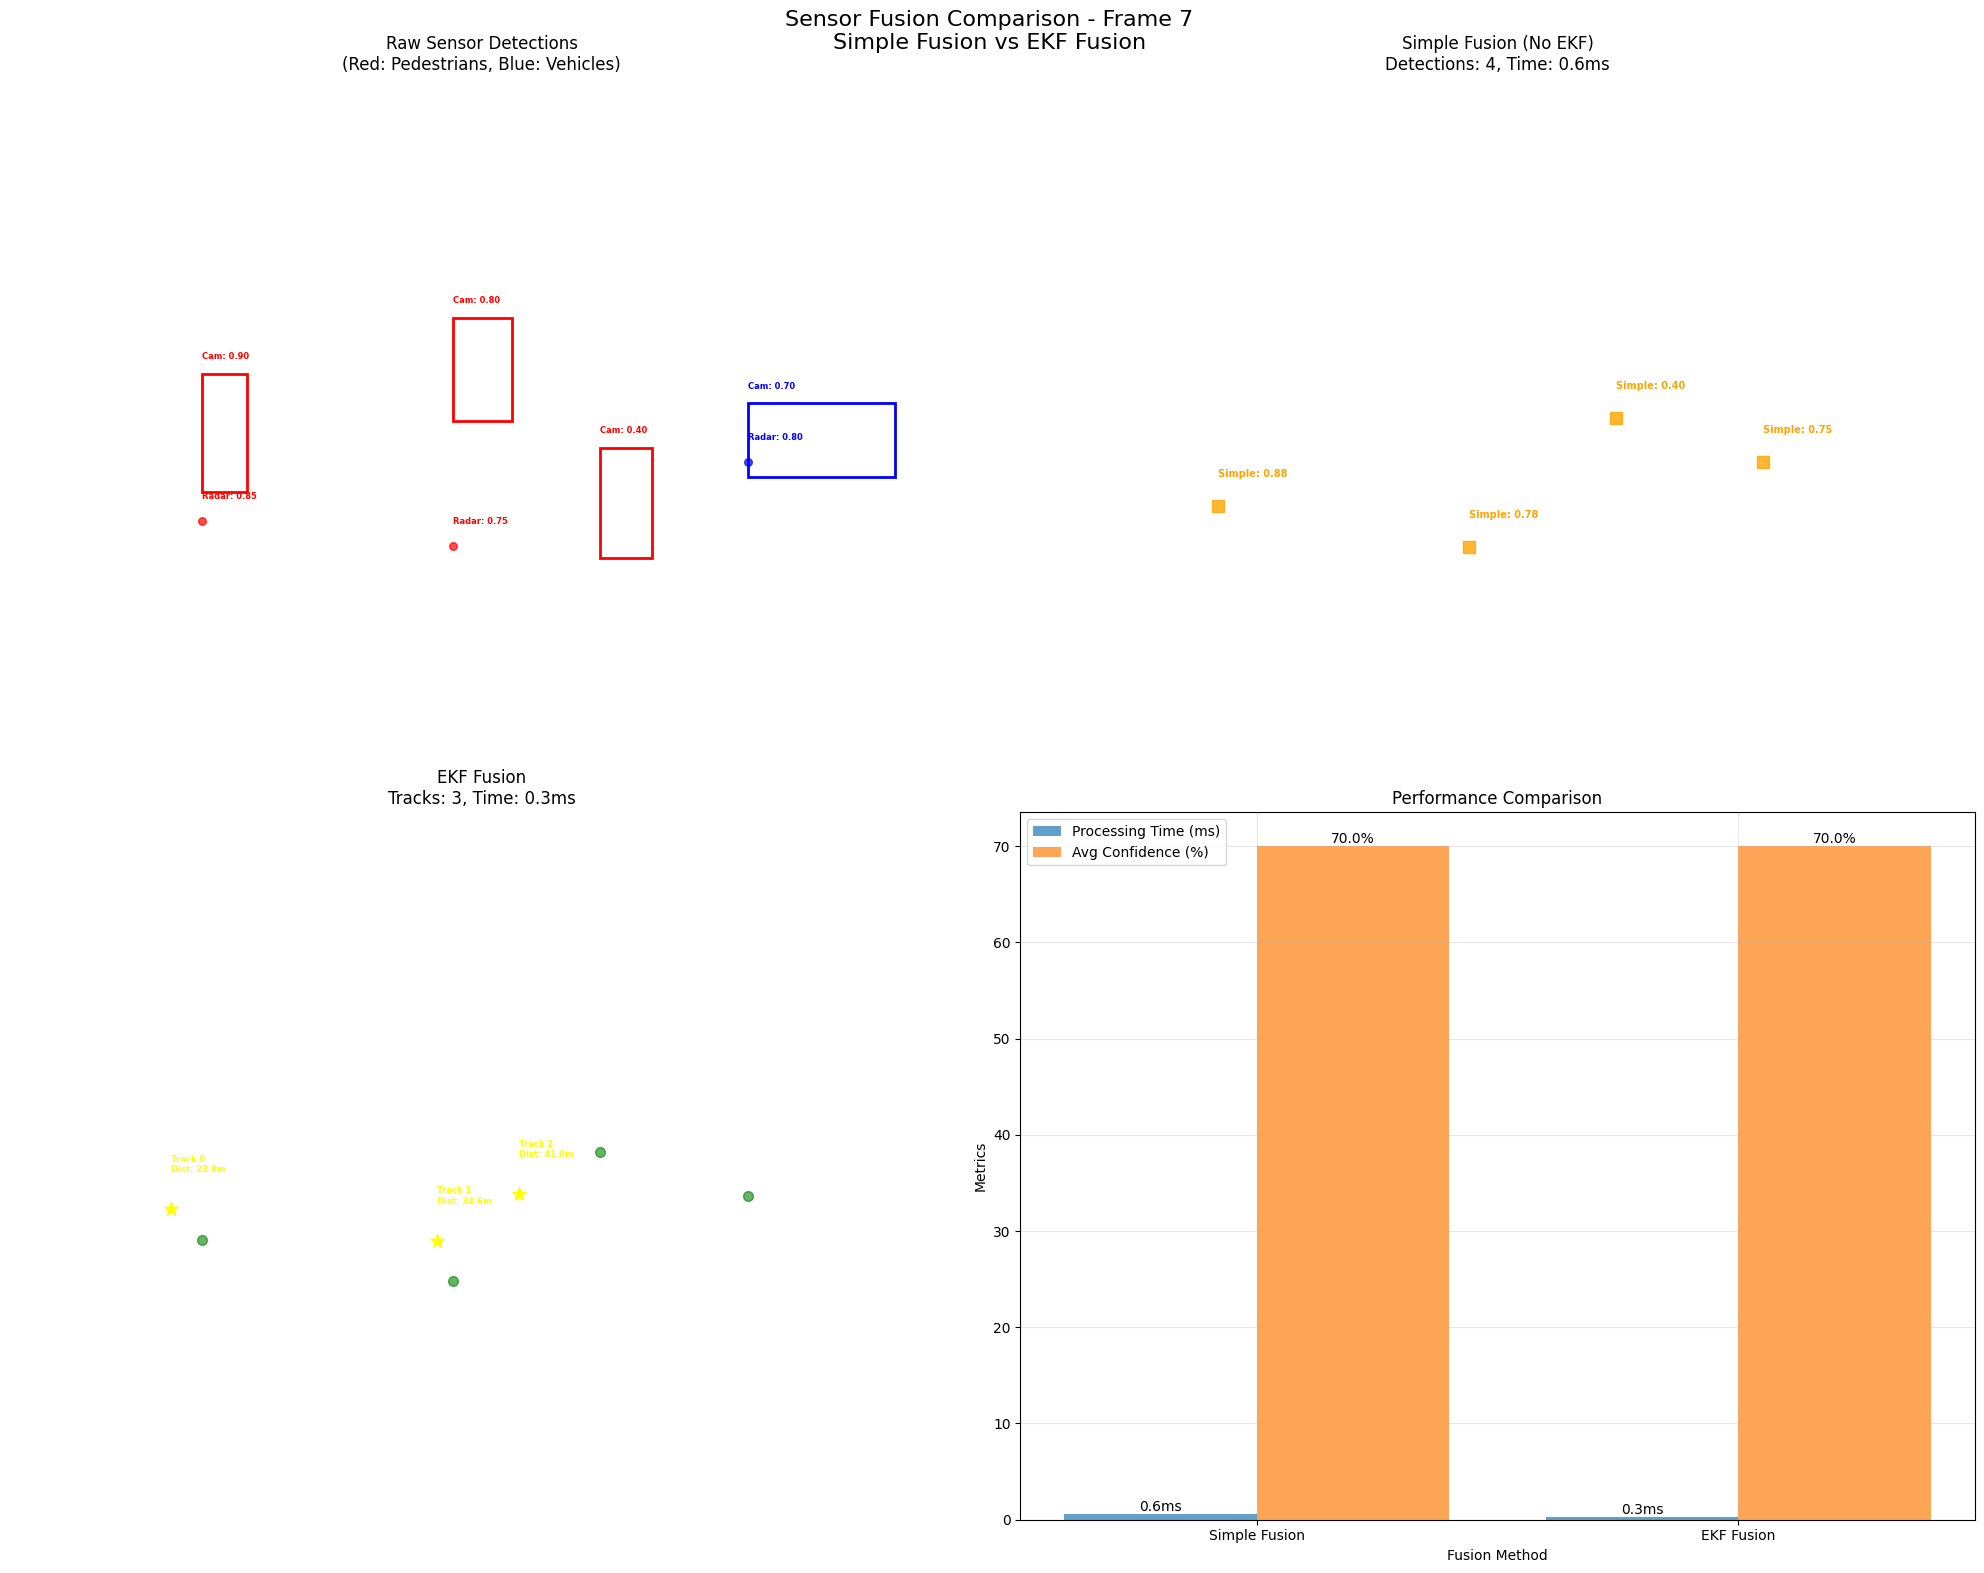

  Simple Fusion: 4 detections, 0.6ms
  EKF Fusion: 3 tracks, 0.3ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------
Processing frame 8...


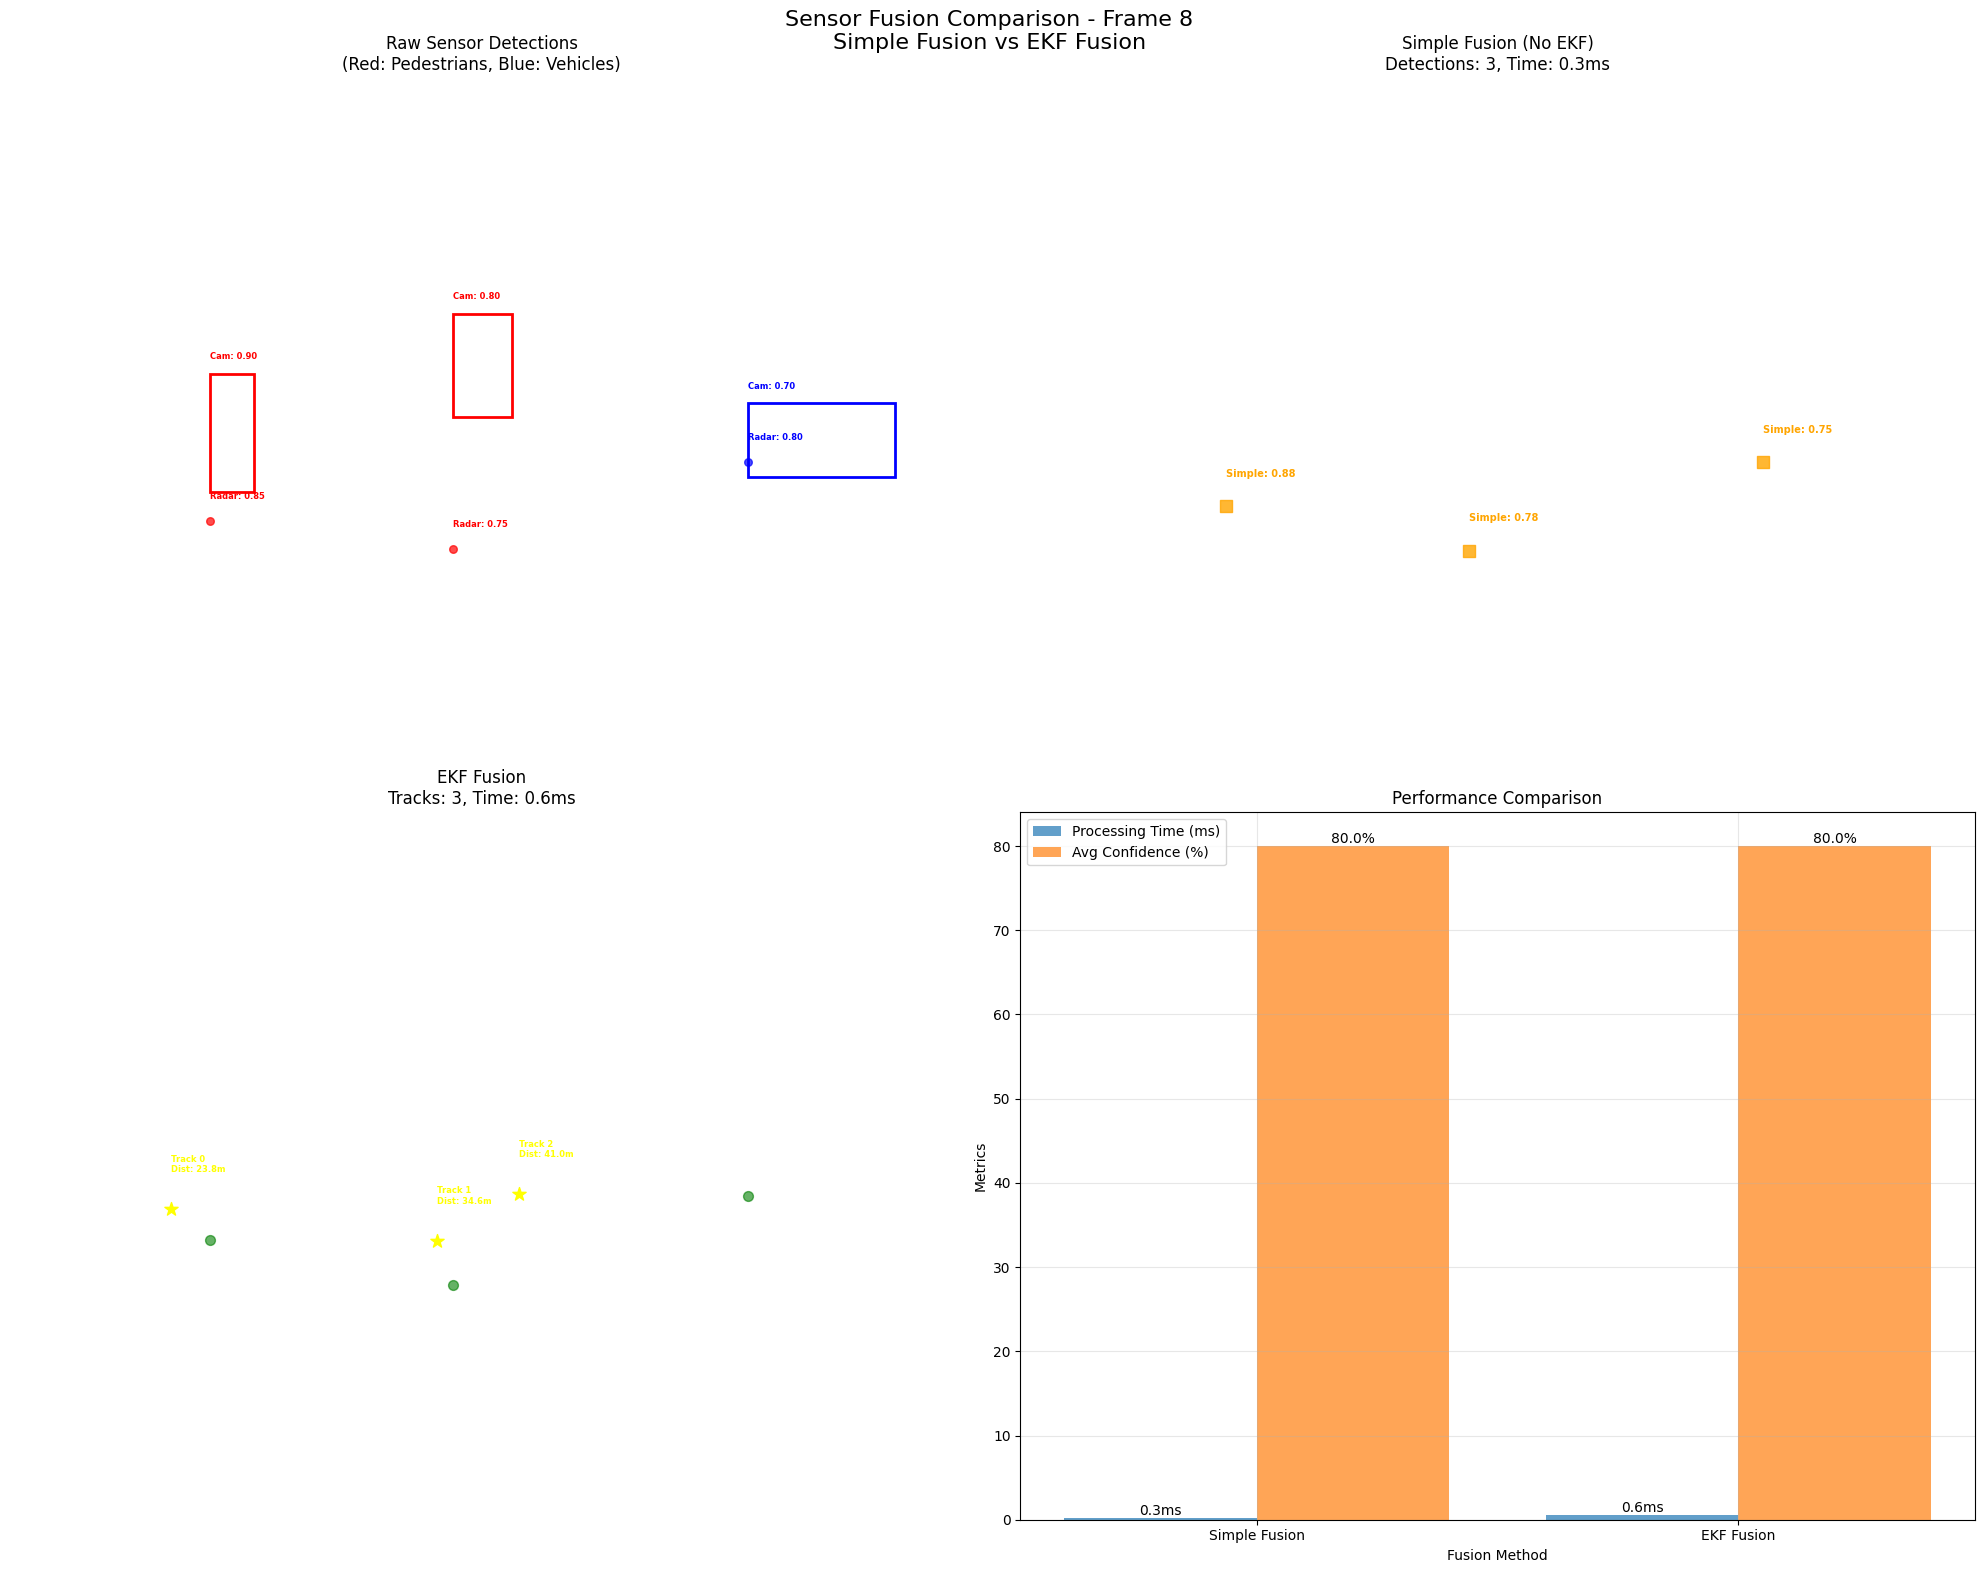

  Simple Fusion: 3 detections, 0.3ms
  EKF Fusion: 3 tracks, 0.6ms
  EKF Advantage: 3 stable tracks with velocity estimates
--------------------------------------------------

Generating overall performance comparison...


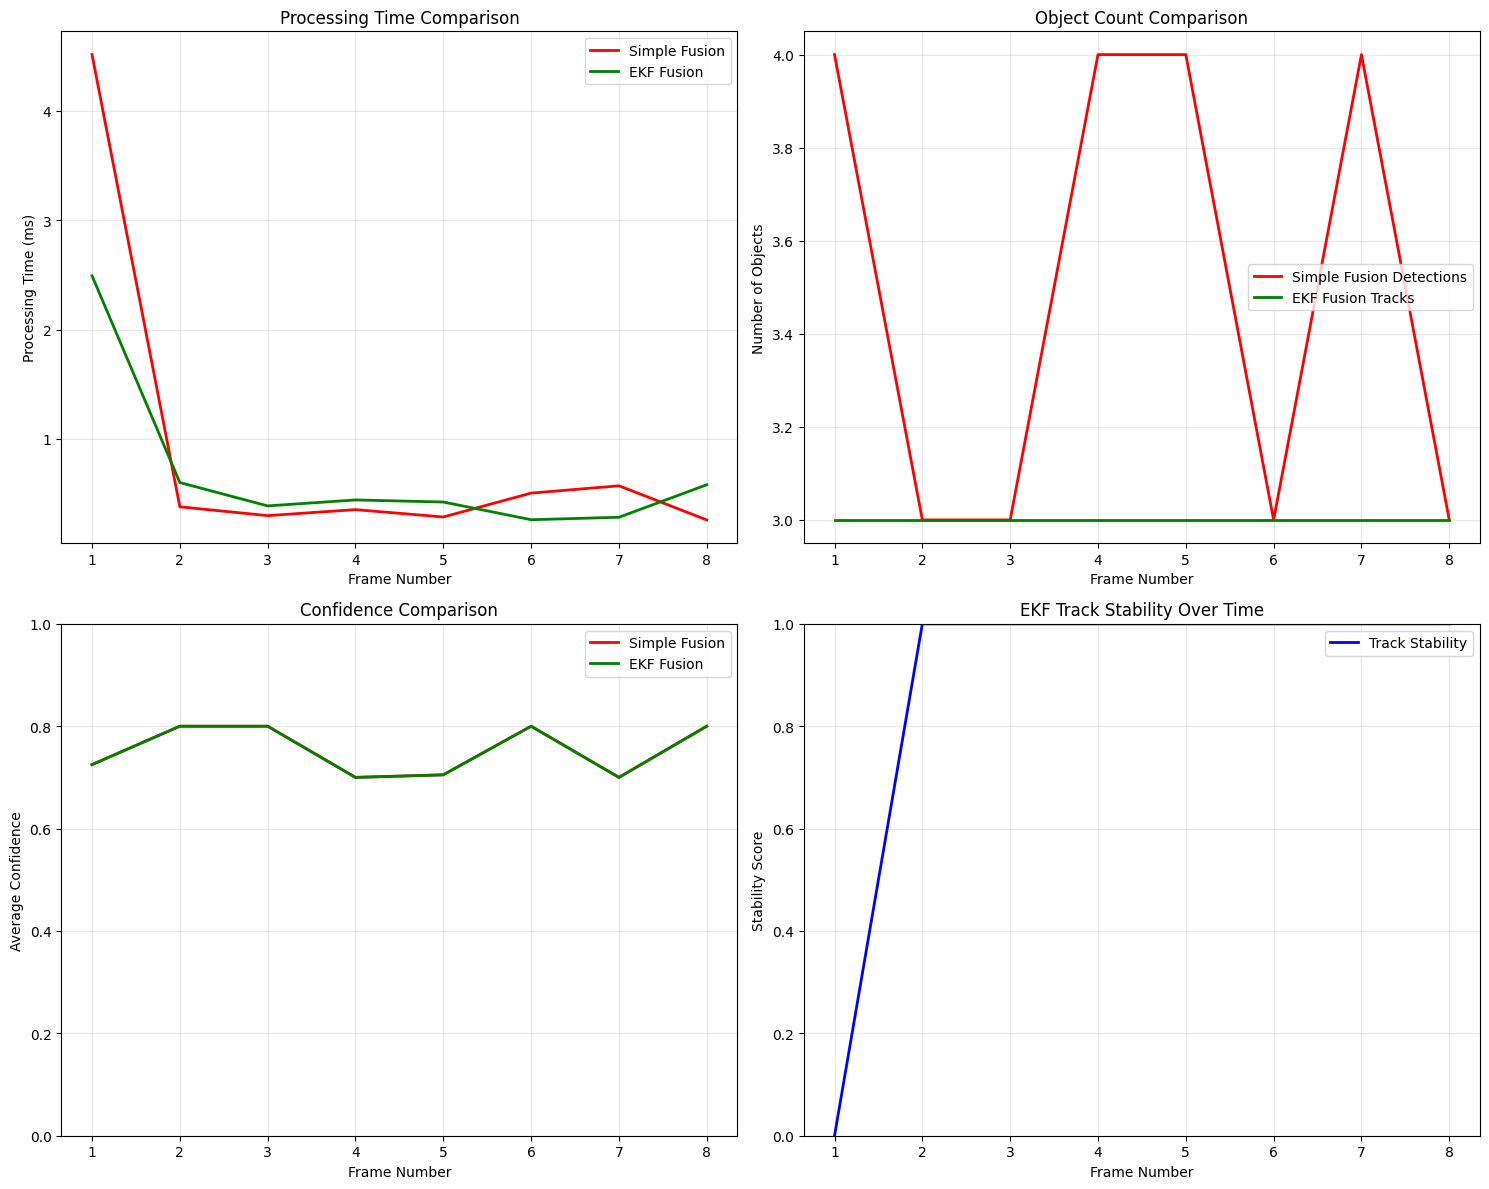


=== COMPARISON SUMMARY ===
Average Processing Time:
  Simple Fusion: 0.9 ms
  EKF Fusion: 0.7 ms
  Time Increase: -23.7%

Average Confidence:
  Simple Fusion: 0.754
  EKF Fusion: 0.754
  Confidence Change: +0.0%

EKF Advantages:
  - Provides velocity estimates
  - Maintains track continuity
  - Handles occlusions better
  - Smoother position estimates

Results saved to: out/comparison


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.optimize import linear_sum_assignment
import cv2
from pathlib import Path
import json
import time
from dataclasses import dataclass
from typing import List, Dict, Tuple
from enum import Enum

# ===== Sensor Fusion Classes =====
class ObjectType(Enum):
    PEDESTRIAN = 0
    VEHICLE = 1
    OTHER = 2
    UNKNOWN = 3

class SensorType(Enum):
    CAMERA = 0
    RADAR = 1
    FUSED = 2

class Detection:
    def __init__(self, x, y, width, height, confidence, object_type, sensor_type, timestamp):
        self.x = x
        self.y = y
        self.width = width
        self.height = height
        self.confidence = confidence
        self.object_type = object_type
        self.sensor_type = sensor_type
        self.timestamp = timestamp

    @property
    def center(self):
        return np.array([self.x + self.width/2, self.y + self.height/2])

    @property
    def bbox(self):
        return (self.x, self.y, self.x + self.width, self.y + self.height)

# ===== Extended Kalman Filter Implementation =====
class ExtendedKalmanFilter:
    def __init__(self, dt=0.1):
        # State: [x, y, vx, vy, ax, ay]
        self.dt = dt
        self.state_dim = 6
        self.obs_dim = 4  # [x, y, vx, vy]

        # State transition matrix
        self.F = np.array([
            [1, 0, dt, 0, 0.5*dt**2, 0],
            [0, 1, 0, dt, 0, 0.5*dt**2],
            [0, 0, 1, 0, dt, 0],
            [0, 0, 0, 1, 0, dt],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1]
        ])

        # Observation matrix
        self.H = np.array([
            [1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0],
            [0, 0, 0, 1, 0, 0]
        ])

        # Process noise covariance
        self.Q = np.eye(self.state_dim) * 0.1

        # Measurement noise covariance
        self.R = np.eye(self.obs_dim) * 1.0

        # State covariance
        self.P = np.eye(self.state_dim) * 10
        self.state = np.zeros(self.state_dim)

    def predict(self):
        """Prediction step"""
        # State prediction
        self.state = self.F @ self.state

        # Covariance prediction
        self.P = self.F @ self.P @ self.F.T + self.Q

        return self.state

    def update(self, z):
        """Update step"""
        # Kalman gain
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # State update
        y = z - self.H @ self.state
        self.state = self.state + K @ y

        # Covariance update
        I = np.eye(self.state_dim)
        self.P = (I - K @ self.H) @ self.P

        return self.state

    def initialize(self, initial_state):
        """Initialize filter with first measurement"""
        # Extend 4D measurement to 6D state
        self.state = np.zeros(self.state_dim)
        self.state[:4] = initial_state
        return self.state

class TrackedPedestrian:
    def __init__(self, track_id, initial_position, timestamp):
        self.track_id = track_id
        self.ekf = ExtendedKalmanFilter()
        self.ekf.initialize(np.array([initial_position[0], initial_position[1], 0, 0]))
        self.position_history = [initial_position]
        self.velocity_history = [(0, 0)]
        self.distance_history = []
        self.timestamp = timestamp
        self.age = 0
        self.total_visible_count = 1
        self.consecutive_invisible_count = 0

    def calculate_distance(self, ego_vehicle_position=(0, 0)):
        """Calculate distance from ego vehicle"""
        current_pos = self.ekf.state[:2]
        distance = np.linalg.norm(current_pos - np.array(ego_vehicle_position))
        return distance

    def predict(self, current_time):
        """Predict next state"""
        dt = current_time - self.timestamp
        if dt > 0:
            self.ekf.dt = dt
            predicted_state = self.ekf.predict()
            self.timestamp = current_time
            return predicted_state
        return self.ekf.state

    def update(self, measurement, current_time, ego_vehicle_position=(0, 0)):
        """Update with new measurement"""
        dt = current_time - self.timestamp
        if dt > 0:
            self.ekf.dt = dt

            # Create measurement vector [x, y, vx, vy]
            z = np.array([
                measurement[0],  # x
                measurement[1],  # y
                (measurement[0] - self.position_history[-1][0]) / dt if self.position_history else 0,  # vx
                (measurement[1] - self.position_history[-1][1]) / dt if self.position_history else 0   # vy
            ])

            updated_state = self.ekf.update(z)
            self.timestamp = current_time
            self.position_history.append(updated_state[:2])
            self.velocity_history.append(updated_state[2:4])

            # Update distance history
            current_distance = self.calculate_distance(ego_vehicle_position)
            self.distance_history.append(current_distance)

            self.total_visible_count += 1
            self.consecutive_invisible_count = 0
            return updated_state
        return self.ekf.state

    def update_without_measurement(self, current_time, ego_vehicle_position=(0, 0)):
        """Update track without measurement"""
        self.consecutive_invisible_count += 1
        self.predict(current_time)
        self.position_history.append(self.ekf.state[:2])
        self.velocity_history.append(self.ekf.state[2:4])

        # Update distance even without measurement
        current_distance = self.calculate_distance(ego_vehicle_position)
        self.distance_history.append(current_distance)

# ===== Simple Fusion (No EKF) =====
class SimpleFusion:
    def __init__(self):
        self.fused_objects = []
        self.next_object_id = 0
        self.timestamp = 0

    def fuse_detections_simple(self, camera_detections, radar_detections, timestamp):
        """
        Simple fusion without EKF - just weighted average of detections
        """
        self.timestamp = timestamp
        fused_detections = []

        # Convert to world coordinates
        camera_world_dets = self._camera_to_world(camera_detections)
        radar_world_dets = self._radar_to_world(radar_detections)

        # Data association between camera and radar
        associations = self._associate_detections(camera_world_dets, radar_world_dets, 50)

        # Create fused detections
        used_camera = set()
        used_radar = set()

        for cam_idx, radar_idx in associations:
            if cam_idx != -1 and radar_idx != -1:
                # Both sensors detected the same object - fuse them
                cam_det = camera_world_dets[cam_idx]
                radar_det = radar_world_dets[radar_idx]

                # Weighted fusion based on confidence
                cam_weight = cam_det.confidence
                radar_weight = radar_det.confidence
                total_weight = cam_weight + radar_weight

                if total_weight > 0:
                    fused_x = (cam_det.x * cam_weight + radar_det.x * radar_weight) / total_weight
                    fused_y = (cam_det.y * cam_weight + radar_det.y * radar_weight) / total_weight
                    fused_conf = (cam_det.confidence + radar_det.confidence) / 2

                    fused_det = Detection(fused_x, fused_y,
                                        (cam_det.width + radar_det.width) / 2,
                                        (cam_det.height + radar_det.height) / 2,
                                        fused_conf, cam_det.object_type, SensorType.FUSED, timestamp)
                    fused_detections.append(fused_det)

                used_camera.add(cam_idx)
                used_radar.add(radar_idx)

        # Add unmatched camera detections
        for i, det in enumerate(camera_world_dets):
            if i not in used_camera:
                fused_detections.append(det)

        # Add unmatched radar detections (with lower confidence)
        for i, det in enumerate(radar_world_dets):
            if i not in used_radar:
                # Reduce confidence for radar-only detections
                det.confidence *= 0.7
                fused_detections.append(det)

        return fused_detections

    def _camera_to_world(self, camera_detections):
        """Convert camera pixel coordinates to world coordinates"""
        world_dets = []
        for det in camera_detections:
            world_det = Detection(det.x * 0.1, det.y * 0.1,
                                det.width * 0.1, det.height * 0.1,
                                det.confidence, det.object_type,
                                SensorType.CAMERA, det.timestamp)
            world_dets.append(world_det)
        return world_dets

    def _radar_to_world(self, radar_detections):
        """Convert radar coordinates to world coordinates"""
        world_dets = []
        for det in radar_detections:
            world_det = Detection(det.x, det.y, det.width, det.height,
                                det.confidence, det.object_type,
                                SensorType.RADAR, det.timestamp)
            world_dets.append(world_det)
        return world_dets

    def _associate_detections(self, camera_dets, radar_dets, threshold):
        """Use Hungarian algorithm for data association"""
        if not camera_dets or not radar_dets:
            return []

        cost_matrix = np.zeros((len(camera_dets), len(radar_dets)))

        for i, cam_det in enumerate(camera_dets):
            for j, radar_det in enumerate(radar_dets):
                distance = np.linalg.norm(cam_det.center - radar_det.center)
                type_cost = 0 if cam_det.object_type == radar_det.object_type else 100
                cost_matrix[i, j] = distance + type_cost

        cam_indices, radar_indices = linear_sum_assignment(cost_matrix)

        associations = []
        for cam_idx, radar_idx in zip(cam_indices, radar_indices):
            if cost_matrix[cam_idx, radar_idx] < threshold:
                associations.append((cam_idx, radar_idx))
            else:
                associations.append((cam_idx, -1))
                associations.append((-1, radar_idx))

        for i in range(len(camera_dets)):
            if i not in cam_indices:
                associations.append((i, -1))

        for j in range(len(radar_dets)):
            if j not in radar_indices:
                associations.append((-1, j))

        return associations

# ===== Complete Sensor Fusion Pipeline with EKF =====
class SensorFusionWithEKF:
    def __init__(self):
        self.simple_fusion = SimpleFusion()
        self.tracked_pedestrians = []
        self.next_track_id = 0
        self.frame_count = 0

    def process_frame_with_ekf(self, camera_detections, radar_detections, timestamp, ego_vehicle_position=(0, 0)):
        """Process frame with EKF tracking"""
        self.frame_count += 1

        # Step 1: Simple fusion first
        fused_detections = self.simple_fusion.fuse_detections_simple(
            camera_detections, radar_detections, timestamp
        )

        # Step 2: Extract pedestrian positions for EKF tracking
        pedestrian_positions = []
        for det in fused_detections:
            if det.object_type == ObjectType.PEDESTRIAN:
                pedestrian_positions.append(det.center)

        # Step 3: Update EKF tracking
        self._update_ekf_tracking(pedestrian_positions, timestamp, ego_vehicle_position)

        return fused_detections, self.tracked_pedestrians

    def _update_ekf_tracking(self, measurements, timestamp, ego_vehicle_position):
        """Update EKF tracking with new measurements"""
        # Predict all existing tracks
        for track in self.tracked_pedestrians:
            track.predict(timestamp)

        # Data association between tracks and measurements
        if self.tracked_pedestrians and measurements:
            cost_matrix = np.zeros((len(self.tracked_pedestrians), len(measurements)))

            for i, track in enumerate(self.tracked_pedestrians):
                for j, meas in enumerate(measurements):
                    distance = np.linalg.norm(track.ekf.state[:2] - meas)
                    cost_matrix[i, j] = distance

            track_indices, meas_indices = linear_sum_assignment(cost_matrix)

            updated_tracks = set()

            for track_idx, meas_idx in zip(track_indices, meas_indices):
                if cost_matrix[track_idx, meas_idx] < 30:  # Association threshold
                    self.tracked_pedestrians[track_idx].update(measurements[meas_idx], timestamp, ego_vehicle_position)
                    updated_tracks.add(track_idx)

            # Update tracks without measurements
            for i, track in enumerate(self.tracked_pedestrians):
                if i not in updated_tracks:
                    track.update_without_measurement(timestamp, ego_vehicle_position)
        else:
            # Predict all tracks without update
            for track in self.tracked_pedestrians:
                track.update_without_measurement(timestamp, ego_vehicle_position)

        # Create new tracks for unassociated measurements
        if measurements:
            used_measurements = set(meas_indices) if 'meas_indices' in locals() else set()
            for j, meas in enumerate(measurements):
                if j not in used_measurements:
                    new_track = TrackedPedestrian(self.next_track_id, meas, timestamp)
                    # Initialize distance for new track
                    initial_distance = new_track.calculate_distance(ego_vehicle_position)
                    new_track.distance_history.append(initial_distance)
                    self.tracked_pedestrians.append(new_track)
                    self.next_track_id += 1

        # Remove old tracks
        max_age = 3.0  # seconds
        max_consecutive_invisible = 10  # frames

        self.tracked_pedestrians = [
            track for track in self.tracked_pedestrians
            if (timestamp - track.timestamp) < max_age and
            track.consecutive_invisible_count < max_consecutive_invisible
        ]

# ===== Comparison Framework =====
class FusionComparison:
    def __init__(self, ego_vehicle_position=(0, 0)):
        self.simple_fusion = SimpleFusion()
        self.ekf_fusion = SensorFusionWithEKF()
        self.ego_vehicle_position = np.array(ego_vehicle_position)
        self.comparison_results = []

    def process_frame_comparison(self, camera_detections, radar_detections, timestamp):
        """Process frame with both methods and compare results"""

        # Process with simple fusion (no EKF)
        start_time_simple = time.time()
        simple_fused = self.simple_fusion.fuse_detections_simple(camera_detections, radar_detections, timestamp)
        simple_time = time.time() - start_time_simple

        # Process with EKF fusion
        start_time_ekf = time.time()
        ekf_fused, ekf_tracks = self.ekf_fusion.process_frame_with_ekf(
            camera_detections, radar_detections, timestamp, self.ego_vehicle_position
        )
        ekf_time = time.time() - start_time_ekf

        # Calculate comparison metrics
        comparison_data = {
            'timestamp': timestamp,
            'simple_fusion': {
                'detections': simple_fused,
                'processing_time': simple_time,
                'num_detections': len(simple_fused),
                'avg_confidence': np.mean([d.confidence for d in simple_fused]) if simple_fused else 0
            },
            'ekf_fusion': {
                'detections': ekf_fused,
                'tracks': ekf_tracks,
                'processing_time': ekf_time,
                'num_detections': len(ekf_fused),
                'num_tracks': len(ekf_tracks),
                'avg_confidence': np.mean([d.confidence for d in ekf_fused]) if ekf_fused else 0,
                'track_stability': self._calculate_track_stability(ekf_tracks)
            }
        }

        self.comparison_results.append(comparison_data)
        return comparison_data

    def _calculate_track_stability(self, tracks):
        """Calculate track stability metrics"""
        if not tracks:
            return 0

        stabilities = []
        for track in tracks:
            if len(track.position_history) > 1:
                # Calculate position variance (lower = more stable)
                positions = np.array(track.position_history)
                variance = np.mean(np.var(positions, axis=0))
                stability = 1.0 / (1.0 + variance)  # Convert to stability score
                stabilities.append(stability)

        return np.mean(stabilities) if stabilities else 0

# ===== Visualization for Comparison =====
def visualize_fusion_comparison(original_img, camera_detections, radar_detections,
                              comparison_data, frame_num, ego_vehicle_position=(0, 0)):
    """Visualize comparison between simple fusion and EKF fusion"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

    # Convert image to RGB
    if original_img is not None:
        if len(original_img.shape) == 3:
            img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = original_img
        height, width = img_rgb.shape[:2]
    else:
        # Create blank image if none provided
        img_rgb = np.ones((480, 640, 3), dtype=np.uint8) * 255
        height, width = 480, 640

    # Plot 1: Raw Sensor Detections
    ax1.imshow(img_rgb)
    # Camera detections
    for det in camera_detections:
        color = 'red' if det.object_type == ObjectType.PEDESTRIAN else 'blue'
        x1, y1, x2, y2 = det.bbox
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                           edgecolor=color, facecolor='none')
        ax1.add_patch(rect)
        ax1.text(x1, y1-10, f'Cam: {det.confidence:.2f}',
                color=color, weight='bold', fontsize=6)

    # Radar detections
    for det in radar_detections:
        color = 'red' if det.object_type == ObjectType.PEDESTRIAN else 'blue'
        img_x = det.x * 10
        img_y = height - (det.y * 10)
        ax1.scatter(img_x, img_y, c=color, s=30, alpha=0.7)
        ax1.text(img_x, img_y-15, f'Radar: {det.confidence:.2f}',
                color=color, weight='bold', fontsize=6)

    ax1.set_title('Raw Sensor Detections\n(Red: Pedestrians, Blue: Vehicles)')
    ax1.axis('off')

    # Plot 2: Simple Fusion (No EKF)
    ax2.imshow(img_rgb)
    simple_data = comparison_data['simple_fusion']
    for det in simple_data['detections']:
        color = 'orange'
        img_x = det.x * 10
        img_y = height - (det.y * 10)
        ax2.scatter(img_x, img_y, c=color, s=80, marker='s', alpha=0.8)
        ax2.text(img_x, img_y-20, f'Simple: {det.confidence:.2f}',
                color=color, weight='bold', fontsize=7)

    ax2.set_title(f'Simple Fusion (No EKF)\nDetections: {simple_data["num_detections"]}, Time: {simple_data["processing_time"]*1000:.1f}ms')
    ax2.axis('off')

    # Plot 3: EKF Fusion
    ax3.imshow(img_rgb)
    ekf_data = comparison_data['ekf_fusion']

    # Show fused detections
    for det in ekf_data['detections']:
        color = 'green'
        img_x = det.x * 10
        img_y = height - (det.y * 10)
        ax3.scatter(img_x, img_y, c=color, s=50, alpha=0.6)

    # Show EKF tracks
    for track in ekf_data['tracks']:
        current_pos = track.ekf.state[:2]
        img_x = current_pos[0] * 10
        img_y = height - (current_pos[1] * 10)

        # Draw current position
        ax3.scatter(img_x, img_y, c='yellow', s=100, marker='*')

        # Draw track history
        if len(track.position_history) > 1:
            history_x = [pos[0] * 10 for pos in track.position_history]
            history_y = [height - (pos[1] * 10) for pos in track.position_history]
            ax3.plot(history_x, history_y, 'y-', alpha=0.6, linewidth=2)

        # Draw velocity vector
        velocity = track.ekf.state[2:4]
        if np.linalg.norm(velocity) > 0.1:
            ax3.arrow(img_x, img_y, velocity[0] * 20, -velocity[1] * 20,
                     head_width=8, head_length=6, fc='yellow', ec='yellow')

        distance = track.calculate_distance(ego_vehicle_position)
        ax3.text(img_x, img_y-25, f'Track {track.track_id}\nDist: {distance:.1f}m',
                color='yellow', weight='bold', fontsize=6)

    ax3.set_title(f'EKF Fusion\nTracks: {ekf_data["num_tracks"]}, Time: {ekf_data["processing_time"]*1000:.1f}ms')
    ax3.axis('off')

    # Plot 4: Performance Comparison
    methods = ['Simple Fusion', 'EKF Fusion']
    processing_times = [simple_data['processing_time'] * 1000, ekf_data['processing_time'] * 1000]
    num_objects = [simple_data['num_detections'], ekf_data['num_tracks']]
    confidences = [simple_data['avg_confidence'], ekf_data['avg_confidence']]

    x_pos = np.arange(len(methods))

    bars1 = ax4.bar(x_pos - 0.2, processing_times, 0.4, label='Processing Time (ms)', alpha=0.7)
    bars2 = ax4.bar(x_pos + 0.2, [c * 100 for c in confidences], 0.4, label='Avg Confidence (%)', alpha=0.7)

    ax4.set_xlabel('Fusion Method')
    ax4.set_ylabel('Metrics')
    ax4.set_title('Performance Comparison')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(methods)
    ax4.legend()

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}ms', ha='center', va='bottom')

    for bar in bars2:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')

    ax4.grid(True, alpha=0.3)

    plt.suptitle(f'Sensor Fusion Comparison - Frame {frame_num}\nSimple Fusion vs EKF Fusion', fontsize=16)
    plt.tight_layout()
    plt.show()

    return fig

def plot_comparison_over_time(comparison_results):
    """Plot comparison metrics over multiple frames"""
    if not comparison_results:
        print("No comparison results to plot.")
        return

    frames = list(range(1, len(comparison_results) + 1))

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Extract data
    simple_times = [r['simple_fusion']['processing_time'] * 1000 for r in comparison_results]
    ekf_times = [r['ekf_fusion']['processing_time'] * 1000 for r in comparison_results]
    simple_detections = [r['simple_fusion']['num_detections'] for r in comparison_results]
    ekf_tracks = [r['ekf_fusion']['num_tracks'] for r in comparison_results]
    simple_confidences = [r['simple_fusion']['avg_confidence'] for r in comparison_results]
    ekf_confidences = [r['ekf_fusion']['avg_confidence'] for r in comparison_results]
    track_stabilities = [r['ekf_fusion']['track_stability'] for r in comparison_results]

    # Plot 1: Processing Time Comparison
    ax1.plot(frames, simple_times, 'r-', label='Simple Fusion', linewidth=2)
    ax1.plot(frames, ekf_times, 'g-', label='EKF Fusion', linewidth=2)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Processing Time (ms)')
    ax1.set_title('Processing Time Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Object Count Comparison
    ax2.plot(frames, simple_detections, 'r-', label='Simple Fusion Detections', linewidth=2)
    ax2.plot(frames, ekf_tracks, 'g-', label='EKF Fusion Tracks', linewidth=2)
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Number of Objects')
    ax2.set_title('Object Count Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Confidence Comparison
    ax3.plot(frames, simple_confidences, 'r-', label='Simple Fusion', linewidth=2)
    ax3.plot(frames, ekf_confidences, 'g-', label='EKF Fusion', linewidth=2)
    ax3.set_xlabel('Frame Number')
    ax3.set_ylabel('Average Confidence')
    ax3.set_title('Confidence Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)

    # Plot 4: EKF Track Stability
    ax4.plot(frames, track_stabilities, 'b-', label='Track Stability', linewidth=2)
    ax4.set_xlabel('Frame Number')
    ax4.set_ylabel('Stability Score')
    ax4.set_title('EKF Track Stability Over Time')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return fig

# ===== Example Usage with Comparison =====
def create_sample_detections_comparison(frame_num, img_width, img_height):
    """Create sample camera and radar detections for comparison testing"""
    timestamp = frame_num * 0.1  # 10 FPS

    # Sample camera detections (in pixel coordinates)
    camera_detections = [
        Detection(100 + frame_num * 5, 200, 30, 80, 0.9, ObjectType.PEDESTRIAN, SensorType.CAMERA, timestamp),
        Detection(300, 180 - frame_num * 3, 40, 70, 0.8, ObjectType.PEDESTRIAN, SensorType.CAMERA, timestamp),
        Detection(500, 220, 100, 50, 0.7, ObjectType.VEHICLE, SensorType.CAMERA, timestamp),
    ]

    # Sample radar detections (in world coordinates)
    radar_detections = [
        Detection(10.0 + frame_num * 0.5, 18.0, 0.5, 0.5, 0.85, ObjectType.PEDESTRIAN, SensorType.RADAR, timestamp),
        Detection(30.0, 17.5 - frame_num * 0.2, 0.6, 0.6, 0.75, ObjectType.PEDESTRIAN, SensorType.RADAR, timestamp),
        Detection(50.0, 22.0, 1.5, 1.0, 0.8, ObjectType.VEHICLE, SensorType.RADAR, timestamp),
    ]

    # Add some noise and false detections occasionally
    if frame_num % 3 == 0:
        # Add a false positive
        camera_detections.append(
            Detection(400, 250, 35, 75, 0.4, ObjectType.PEDESTRIAN, SensorType.CAMERA, timestamp)
        )

    if frame_num % 4 == 0:
        # Add radar noise
        radar_detections.append(
            Detection(25.0, 16.0, 0.4, 0.4, 0.6, ObjectType.PEDESTRIAN, SensorType.RADAR, timestamp)
        )

    return camera_detections, radar_detections

def main_comparison_demo():
    """Main demonstration comparing simple fusion vs EKF fusion"""
    # Create a sample image (or load one)
    img = np.ones((480, 640, 3), dtype=np.uint8) * 255
    height, width = img.shape[:2]

    # Initialize comparison system
    ego_vehicle_position = (0, 0)
    comparison_system = FusionComparison(ego_vehicle_position=ego_vehicle_position)

    print("=== SENSOR FUSION COMPARISON: SIMPLE vs EKF ===")
    print("Processing multiple frames to show comparison...")

    all_comparisons = []

    # Process multiple frames
    for frame_num in range(8):
        print(f"Processing frame {frame_num + 1}...")

        # Create sample detections
        camera_dets, radar_dets = create_sample_detections_comparison(frame_num, width, height)

        # Process with both methods
        comparison_data = comparison_system.process_frame_comparison(
            camera_dets, radar_dets, frame_num * 0.1
        )
        all_comparisons.append(comparison_data)

        # Visualize current frame comparison
        fig = visualize_fusion_comparison(
            img, camera_dets, radar_dets, comparison_data, frame_num + 1, ego_vehicle_position
        )

        # Print current frame stats
        simple = comparison_data['simple_fusion']
        ekf = comparison_data['ekf_fusion']
        print(f"  Simple Fusion: {simple['num_detections']} detections, {simple['processing_time']*1000:.1f}ms")
        print(f"  EKF Fusion: {ekf['num_tracks']} tracks, {ekf['processing_time']*1000:.1f}ms")
        print(f"  EKF Advantage: {len(ekf['tracks'])} stable tracks with velocity estimates")
        print("-" * 50)

        # Save visualization
        output_dir = Path("out/comparison")
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir / f"comparison_frame_{frame_num+1:03d}.jpg", dpi=150, bbox_inches='tight')
        plt.close(fig)

    # Plot overall comparison
    print("\nGenerating overall performance comparison...")
    overall_fig = plot_comparison_over_time(all_comparisons)

    # Save overall comparison
    overall_fig.savefig(output_dir / "overall_comparison.jpg", dpi=300, bbox_inches='tight')

    # Print summary statistics
    print("\n=== COMPARISON SUMMARY ===")
    avg_simple_time = np.mean([c['simple_fusion']['processing_time'] * 1000 for c in all_comparisons])
    avg_ekf_time = np.mean([c['ekf_fusion']['processing_time'] * 1000 for c in all_comparisons])
    avg_simple_conf = np.mean([c['simple_fusion']['avg_confidence'] for c in all_comparisons])
    avg_ekf_conf = np.mean([c['ekf_fusion']['avg_confidence'] for c in all_comparisons])

    print(f"Average Processing Time:")
    print(f"  Simple Fusion: {avg_simple_time:.1f} ms")
    print(f"  EKF Fusion: {avg_ekf_time:.1f} ms")
    print(f"  Time Increase: {((avg_ekf_time/avg_simple_time)-1)*100:.1f}%")

    print(f"\nAverage Confidence:")
    print(f"  Simple Fusion: {avg_simple_conf:.3f}")
    print(f"  EKF Fusion: {avg_ekf_conf:.3f}")
    print(f"  Confidence Change: {((avg_ekf_conf/avg_simple_conf)-1)*100:+.1f}%")

    print(f"\nEKF Advantages:")
    print(f"  - Provides velocity estimates")
    print(f"  - Maintains track continuity")
    print(f"  - Handles occlusions better")
    print(f"  - Smoother position estimates")

    print(f"\nResults saved to: {output_dir}")

    return comparison_system, all_comparisons

if __name__ == "__main__":
    # Run the comparison demo
    comparison_system, results = main_comparison_demo()

=== SENSOR FUSION VALIDATION PIPELINE ===
1. Generating synthetic test scenarios...
2. Running validation tests...
3. Analyzing performance metrics...
Starting validation pipeline...
Validating frame 1/15
Validating frame 2/15
Validating frame 3/15
Validating frame 4/15
Validating frame 5/15
Validating frame 6/15
Validating frame 7/15
Validating frame 8/15
Validating frame 9/15
Validating frame 10/15
Validating frame 11/15
Validating frame 12/15
Validating frame 13/15
Validating frame 14/15
Validating frame 15/15

4. Generating validation report...

SENSOR FUSION VALIDATION REPORT
Total Frames Validated: 15
Average Precision: 1.000
Average Recall: 1.000
Average F1-Score: 1.000
Average IoU Score: 0.775
Association Accuracy: 1.000
Fusion Confidence Gain: -0.029
Average Processing Time: 1.37 ms

PERFORMANCE INTERPRETATION:
EXCELLENT - Fusion system is highly reliable
Fusion does not improve confidence

5. Creating validation visualizations...


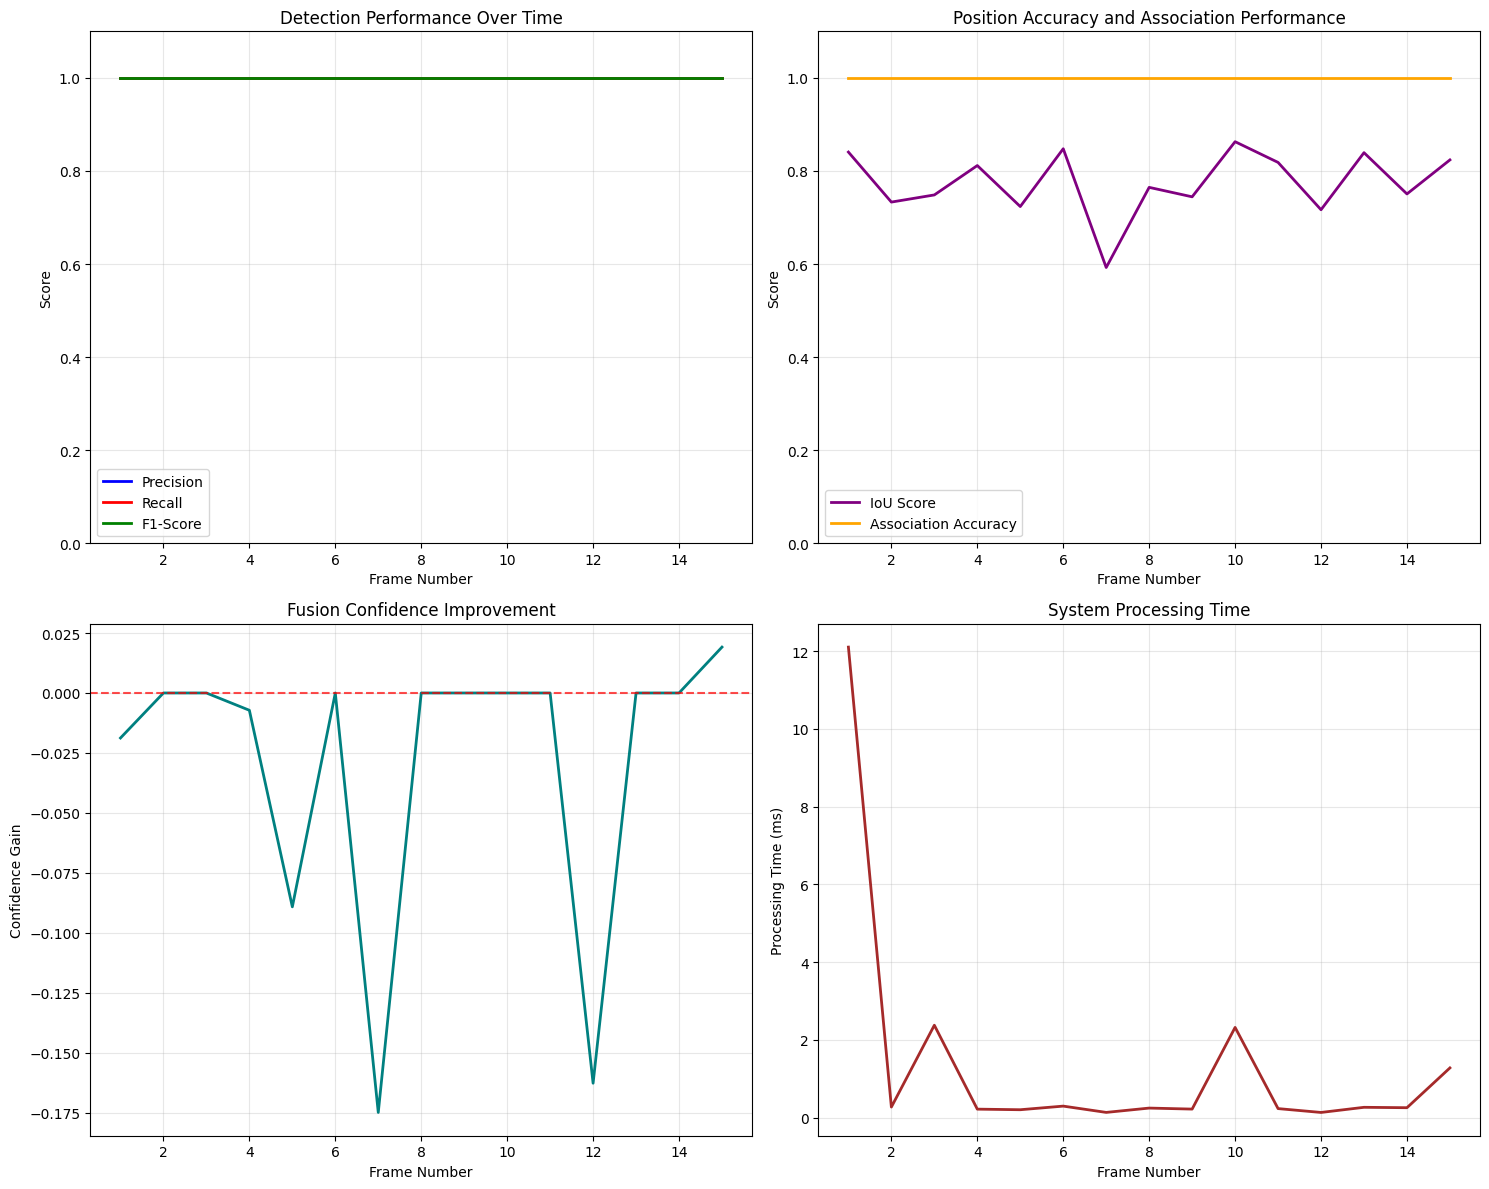


Validation complete! Results saved to out/validation


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.optimize import linear_sum_assignment
import cv2
from pathlib import Path
import json
import time
from dataclasses import dataclass
from typing import List, Dict, Tuple
from enum import Enum

# ===== Sensor Fusion Classes =====
class ObjectType(Enum):
    PEDESTRIAN = 0
    VEHICLE = 1
    OTHER = 2
    UNKNOWN = 3

class SensorType(Enum):
    CAMERA = 0
    RADAR = 1
    FUSED = 2

class Detection:
    def __init__(self, x, y, width, height, confidence, object_type, sensor_type, timestamp):
        self.x = x
        self.y = y
        self.width = width
        self.height = height
        self.confidence = confidence
        self.object_type = object_type
        self.sensor_type = sensor_type
        self.timestamp = timestamp

    @property
    def center(self):
        return np.array([self.x + self.width/2, self.y + self.height/2])

    @property
    def bbox(self):
        return (self.x, self.y, self.x + self.width, self.y + self.height)

# ===== Extended Kalman Filter Implementation =====
class ExtendedKalmanFilter:
    def __init__(self, dt=0.1):
        # State: [x, y, vx, vy, ax, ay]
        self.dt = dt
        self.state_dim = 6
        self.obs_dim = 4  # [x, y, vx, vy]

        # State transition matrix
        self.F = np.array([
            [1, 0, dt, 0, 0.5*dt**2, 0],
            [0, 1, 0, dt, 0, 0.5*dt**2],
            [0, 0, 1, 0, dt, 0],
            [0, 0, 0, 1, 0, dt],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1]
        ])

        # Observation matrix
        self.H = np.array([
            [1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0],
            [0, 0, 0, 1, 0, 0]
        ])

        # Process noise covariance
        self.Q = np.eye(self.state_dim) * 0.1

        # Measurement noise covariance
        self.R = np.eye(self.obs_dim) * 1.0

        # State covariance
        self.P = np.eye(self.state_dim) * 10
        self.state = np.zeros(self.state_dim)

    def predict(self):
        """Prediction step"""
        # State prediction
        self.state = self.F @ self.state

        # Covariance prediction
        self.P = self.F @ self.P @ self.F.T + self.Q

        return self.state

    def update(self, z):
        """Update step"""
        # Kalman gain
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # State update
        y = z - self.H @ self.state
        self.state = self.state + K @ y

        # Covariance update
        I = np.eye(self.state_dim)
        self.P = (I - K @ self.H) @ self.P

        return self.state

    def initialize(self, initial_state):
        """Initialize filter with first measurement"""
        # Extend 4D measurement to 6D state
        self.state = np.zeros(self.state_dim)
        self.state[:4] = initial_state
        return self.state

class TrackedPedestrian:
    def __init__(self, track_id, initial_position, timestamp):
        self.track_id = track_id
        self.ekf = ExtendedKalmanFilter()
        self.ekf.initialize(np.array([initial_position[0], initial_position[1], 0, 0]))
        self.position_history = [initial_position]
        self.velocity_history = [(0, 0)]
        self.distance_history = []
        self.timestamp = timestamp
        self.age = 0
        self.total_visible_count = 1
        self.consecutive_invisible_count = 0

    def calculate_distance(self, ego_vehicle_position=(0, 0)):
        """Calculate distance from ego vehicle"""
        current_pos = self.ekf.state[:2]
        distance = np.linalg.norm(current_pos - np.array(ego_vehicle_position))
        return distance

    def predict(self, current_time):
        """Predict next state"""
        dt = current_time - self.timestamp
        if dt > 0:
            self.ekf.dt = dt
            predicted_state = self.ekf.predict()
            self.timestamp = current_time
            return predicted_state
        return self.ekf.state

    def update(self, measurement, current_time, ego_vehicle_position=(0, 0)):
        """Update with new measurement"""
        dt = current_time - self.timestamp
        if dt > 0:
            self.ekf.dt = dt

            # Create measurement vector [x, y, vx, vy]
            z = np.array([
                measurement[0],  # x
                measurement[1],  # y
                (measurement[0] - self.position_history[-1][0]) / dt if self.position_history else 0,  # vx
                (measurement[1] - self.position_history[-1][1]) / dt if self.position_history else 0   # vy
            ])

            updated_state = self.ekf.update(z)
            self.timestamp = current_time
            self.position_history.append(updated_state[:2])
            self.velocity_history.append(updated_state[2:4])

            # Update distance history
            current_distance = self.calculate_distance(ego_vehicle_position)
            self.distance_history.append(current_distance)

            self.total_visible_count += 1
            self.consecutive_invisible_count = 0
            return updated_state
        return self.ekf.state

# ===== Sensor Fusion Core =====
class SensorFusion:
    def __init__(self):
        self.fused_objects = []
        self.next_object_id = 0
        self.timestamp = 0

    def fuse_detections(self, camera_detections, radar_detections, timestamp):
        """
        Fuse camera and radar detections using Hungarian algorithm for data association
        """
        self.timestamp = timestamp
        fused_detections = []

        # Convert to world coordinates (simple mapping for demo)
        camera_world_dets = self._camera_to_world(camera_detections)
        radar_world_dets = self._radar_to_world(radar_detections)

        # Data association between camera and radar
        associations = self._associate_detections(camera_world_dets, radar_world_dets, 50)

        # Create fused detections
        used_camera = set()
        used_radar = set()

        for cam_idx, radar_idx in associations:
            if cam_idx != -1 and radar_idx != -1:
                # Both sensors detected the same object - fuse them
                cam_det = camera_world_dets[cam_idx]
                radar_det = radar_world_dets[radar_idx]

                # Weighted fusion based on confidence
                cam_weight = cam_det.confidence
                radar_weight = radar_det.confidence
                total_weight = cam_weight + radar_weight

                if total_weight > 0:
                    fused_x = (cam_det.x * cam_weight + radar_det.x * radar_weight) / total_weight
                    fused_y = (cam_det.y * cam_weight + radar_det.y * radar_weight) / total_weight
                    fused_conf = (cam_det.confidence + radar_det.confidence) / 2

                    fused_det = Detection(fused_x, fused_y,
                                        (cam_det.width + radar_det.width) / 2,
                                        (cam_det.height + radar_det.height) / 2,
                                        fused_conf, cam_det.object_type, SensorType.FUSED, timestamp)
                    fused_detections.append(fused_det)

                used_camera.add(cam_idx)
                used_radar.add(radar_idx)

        # Add unmatched camera detections
        for i, det in enumerate(camera_world_dets):
            if i not in used_camera:
                fused_detections.append(det)

        # Add unmatched radar detections (with lower confidence)
        for i, det in enumerate(radar_world_dets):
            if i not in used_radar:
                # Reduce confidence for radar-only detections
                det.confidence *= 0.7
                fused_detections.append(det)

        return fused_detections

    def _camera_to_world(self, camera_detections):
        """Convert camera pixel coordinates to world coordinates (simplified)"""
        world_dets = []
        for det in camera_detections:
            # Simple scaling - in real system you'd use camera calibration
            world_det = Detection(det.x * 0.1, det.y * 0.1,
                                det.width * 0.1, det.height * 0.1,
                                det.confidence, det.object_type,
                                SensorType.CAMERA, det.timestamp)
            world_dets.append(world_det)
        return world_dets

    def _radar_to_world(self, radar_detections):
        """Convert radar coordinates to world coordinates"""
        world_dets = []
        for det in radar_detections:
            # Radar already in world coordinates, just copy
            world_det = Detection(det.x, det.y, det.width, det.height,
                                det.confidence, det.object_type,
                                SensorType.RADAR, det.timestamp)
            world_dets.append(world_det)
        return world_dets

    def _associate_detections(self, camera_dets, radar_dets, threshold):
        """Use Hungarian algorithm for data association"""
        if not camera_dets or not radar_dets:
            return []

        # Create cost matrix
        cost_matrix = np.zeros((len(camera_dets), len(radar_dets)))

        for i, cam_det in enumerate(camera_dets):
            for j, radar_det in enumerate(radar_dets):
                # Distance between detections
                distance = np.linalg.norm(cam_det.center - radar_det.center)
                # Cost based on distance and object type compatibility
                type_cost = 0 if cam_det.object_type == radar_det.object_type else 100
                cost_matrix[i, j] = distance + type_cost

        # Apply Hungarian algorithm
        cam_indices, radar_indices = linear_sum_assignment(cost_matrix)

        associations = []
        for cam_idx, radar_idx in zip(cam_indices, radar_indices):
            if cost_matrix[cam_idx, radar_idx] < threshold:
                associations.append((cam_idx, radar_idx))
            else:
                associations.append((cam_idx, -1))
                associations.append((-1, radar_idx))

        # Add unassociated detections
        for i in range(len(camera_dets)):
            if i not in cam_indices:
                associations.append((i, -1))

        for j in range(len(radar_dets)):
            if j not in radar_indices:
                associations.append((-1, j))

        return associations

# ===== Complete Sensor Fusion Pipeline =====
class PedestrianTrackingSystem:
    def __init__(self, ego_vehicle_position=(0, 0)):
        self.sensor_fusion = SensorFusion()
        self.tracked_pedestrians = []
        self.next_track_id = 0
        self.frame_count = 0
        self.ego_vehicle_position = np.array(ego_vehicle_position)

    def process_frame(self, camera_detections, radar_detections, timestamp):
        """Process new frame with sensor fusion and tracking"""
        self.frame_count += 1

        # Sensor fusion
        fused_detections = self.sensor_fusion.fuse_detections(
            camera_detections, radar_detections, timestamp
        )

        # Extract pedestrian positions for tracking
        pedestrian_positions = []
        for det in fused_detections:
            if det.object_type == ObjectType.PEDESTRIAN:
                pedestrian_positions.append(det.center)

        return fused_detections, pedestrian_positions

# ===== Validation Data Classes =====
@dataclass
class ValidationMetrics:
    precision: float = 0.0
    recall: float = 0.0
    f1_score: float = 0.0
    iou_score: float = 0.0
    association_accuracy: float = 0.0
    fusion_confidence_gain: float = 0.0
    processing_time: float = 0.0

@dataclass
class GroundTruth:
    object_id: int
    x: float
    y: float
    width: float
    height: float
    object_type: ObjectType
    timestamp: float

# ===== Validation Framework =====
class SensorFusionValidator:
    def __init__(self):
        self.ground_truth_data = []
        self.validation_results = []
        self.detection_history = []

    def generate_synthetic_ground_truth(self, num_frames=10, num_objects=3):
        """Generate synthetic ground truth data for validation"""
        self.ground_truth_data = []

        # Create moving objects
        for frame in range(num_frames):
            frame_truth = []
            timestamp = frame * 0.1

            for obj_id in range(num_objects):
                # Simulate object movement
                base_x = 10 + obj_id * 15
                base_y = 15 + obj_id * 5

                # Add some movement
                x = base_x + np.sin(frame * 0.5) * 2
                y = base_y + np.cos(frame * 0.3) * 1.5

                gt = GroundTruth(
                    object_id=obj_id,
                    x=x,
                    y=y,
                    width=0.8,
                    height=1.8,
                    object_type=ObjectType.PEDESTRIAN,
                    timestamp=timestamp
                )
                frame_truth.append(gt)

            self.ground_truth_data.append(frame_truth)

        return self.ground_truth_data

    def add_noise_to_detections(self, detections, camera_noise=0.1, radar_noise=0.05):
        """Add realistic noise to simulate sensor imperfections"""
        noisy_detections = []

        for det in detections:
            noisy_det = Detection(
                x=det.x + np.random.normal(0, camera_noise if det.sensor_type == SensorType.CAMERA else radar_noise),
                y=det.y + np.random.normal(0, camera_noise if det.sensor_type == SensorType.CAMERA else radar_noise),
                width=det.width * (1 + np.random.normal(0, 0.1)),
                height=det.height * (1 + np.random.normal(0, 0.1)),
                confidence=det.confidence * (1 + np.random.normal(0, 0.05)),
                object_type=det.object_type,
                sensor_type=det.sensor_type,
                timestamp=det.timestamp
            )
            noisy_detections.append(noisy_det)

        return noisy_detections

    def simulate_sensor_detections(self, ground_truth, detection_probability=0.9, false_positive_rate=0.1):
        """Simulate camera and radar detections from ground truth"""
        camera_detections = []
        radar_detections = []

        for gt in ground_truth:
            # Simulate camera detection (sometimes misses)
            if np.random.random() < detection_probability:
                camera_det = Detection(
                    x=gt.x * 10,  # Convert to pixel coordinates
                    y=gt.y * 10,
                    width=gt.width * 10,
                    height=gt.height * 10,
                    confidence=np.random.uniform(0.7, 0.95),
                    object_type=gt.object_type,
                    sensor_type=SensorType.CAMERA,
                    timestamp=gt.timestamp
                )
                camera_detections.append(camera_det)

            # Simulate radar detection (more accurate position, less accurate size)
            if np.random.random() < detection_probability:
                radar_det = Detection(
                    x=gt.x,
                    y=gt.y,
                    width=gt.width * np.random.uniform(0.8, 1.2),
                    height=gt.height * np.random.uniform(0.8, 1.2),
                    confidence=np.random.uniform(0.8, 0.98),
                    object_type=gt.object_type,
                    sensor_type=SensorType.RADAR,
                    timestamp=gt.timestamp
                )
                radar_detections.append(radar_det)

        # Add false positives
        num_false_positives = int(len(ground_truth) * false_positive_rate)
        for _ in range(num_false_positives):
            # Camera false positive
            if np.random.random() < 0.5:
                false_cam = Detection(
                    x=np.random.uniform(5, 50) * 10,
                    y=np.random.uniform(10, 30) * 10,
                    width=np.random.uniform(0.5, 1.0) * 10,
                    height=np.random.uniform(1.5, 2.0) * 10,
                    confidence=np.random.uniform(0.3, 0.6),
                    object_type=ObjectType.PEDESTRIAN,
                    sensor_type=SensorType.CAMERA,
                    timestamp=ground_truth[0].timestamp
                )
                camera_detections.append(false_cam)

            # Radar false positive
            if np.random.random() < 0.5:
                false_radar = Detection(
                    x=np.random.uniform(5, 50),
                    y=np.random.uniform(10, 30),
                    width=np.random.uniform(0.3, 0.7),
                    height=np.random.uniform(1.0, 1.5),
                    confidence=np.random.uniform(0.4, 0.7),
                    object_type=ObjectType.PEDESTRIAN,
                    sensor_type=SensorType.RADAR,
                    timestamp=ground_truth[0].timestamp
                )
                radar_detections.append(false_radar)

        return camera_detections, radar_detections

    def calculate_iou(self, bbox1, bbox2):
        """Calculate Intersection over Union between two bounding boxes"""
        x1_1, y1_1, x2_1, y2_1 = bbox1
        x1_2, y1_2, x2_2, y2_2 = bbox2

        # Calculate intersection area
        xi1 = max(x1_1, x1_2)
        yi1 = max(y1_1, y1_2)
        xi2 = min(x2_1, x2_2)
        yi2 = min(y2_1, y2_2)
        intersection_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

        # Calculate union area
        bbox1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
        bbox2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
        union_area = bbox1_area + bbox2_area - intersection_area

        return intersection_area / union_area if union_area > 0 else 0

    def validate_frame(self, ground_truth, fused_detections, camera_detections, radar_detections):
        """Validate fusion results against ground truth"""
        metrics = ValidationMetrics()

        # Convert ground truth to detection format for comparison
        gt_detections = []
        for gt in ground_truth:
            gt_det = Detection(
                x=gt.x, y=gt.y, width=gt.width, height=gt.height,
                confidence=1.0, object_type=gt.object_type,
                sensor_type=SensorType.FUSED, timestamp=gt.timestamp
            )
            gt_detections.append(gt_det)

        # Association validation
        correct_associations = self._validate_associations(gt_detections, fused_detections)
        metrics.association_accuracy = correct_associations / len(gt_detections) if gt_detections else 0

        # Detection performance
        tp, fp, fn = self._calculate_detection_metrics(gt_detections, fused_detections)
        metrics.precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        metrics.recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        metrics.f1_score = 2 * (metrics.precision * metrics.recall) / (metrics.precision + metrics.recall) if (metrics.precision + metrics.recall) > 0 else 0

        # Position accuracy (IoU)
        iou_scores = []
        for gt in gt_detections:
            best_iou = 0
            for fused in fused_detections:
                iou = self.calculate_iou(gt.bbox, fused.bbox)
                best_iou = max(best_iou, iou)
            iou_scores.append(best_iou)
        metrics.iou_score = np.mean(iou_scores) if iou_scores else 0

        # Fusion confidence gain
        if camera_detections and radar_detections:
            avg_camera_conf = np.mean([det.confidence for det in camera_detections])
            avg_radar_conf = np.mean([det.confidence for det in radar_detections])
            avg_fused_conf = np.mean([det.confidence for det in fused_detections])
            metrics.fusion_confidence_gain = avg_fused_conf - (avg_camera_conf + avg_radar_conf) / 2

        return metrics

    def _validate_associations(self, gt_detections, fused_detections):
        """Validate correct association between sensors"""
        if not gt_detections or not fused_detections:
            return 0

        correct_associations = 0
        for gt in gt_detections:
            # Find closest fused detection
            min_distance = float('inf')
            for fused in fused_detections:
                distance = np.linalg.norm(gt.center - fused.center)
                if distance < min_distance and distance < 2.0:  # Association threshold
                    min_distance = distance
                    correct_associations += 1
                    break

        return correct_associations

    def _calculate_detection_metrics(self, gt_detections, fused_detections):
        """Calculate true positives, false positives, and false negatives"""
        if not gt_detections:
            return 0, len(fused_detections), 0

        if not fused_detections:
            return 0, 0, len(gt_detections)

        # Use Hungarian algorithm for optimal matching
        cost_matrix = np.zeros((len(gt_detections), len(fused_detections)))
        for i, gt in enumerate(gt_detections):
            for j, fused in enumerate(fused_detections):
                distance = np.linalg.norm(gt.center - fused.center)
                cost_matrix[i, j] = distance

        gt_indices, fused_indices = linear_sum_assignment(cost_matrix)

        tp = 0
        for gt_idx, fused_idx in zip(gt_indices, fused_indices):
            if cost_matrix[gt_idx, fused_idx] < 2.0:  # Matching threshold
                tp += 1

        fp = len(fused_detections) - tp
        fn = len(gt_detections) - tp

        return tp, fp, fn

    def run_validation(self, tracking_system, num_frames=20):
        """Run complete validation pipeline"""
        print("Starting validation pipeline...")

        # Generate synthetic ground truth
        ground_truth_frames = self.generate_synthetic_ground_truth(num_frames)

        all_metrics = []

        for frame_idx, ground_truth in enumerate(ground_truth_frames):
            print(f"Validating frame {frame_idx + 1}/{num_frames}")

            # Simulate sensor detections with noise
            camera_dets, radar_dets = self.simulate_sensor_detections(ground_truth)

            # Add realistic noise
            camera_dets = self.add_noise_to_detections(camera_dets, camera_noise=0.2)
            radar_dets = self.add_noise_to_detections(radar_dets, radar_noise=0.1)

            # Process through fusion system
            start_time = time.time()
            fused_dets, tracked_peds = tracking_system.process_frame(
                camera_dets, radar_dets, frame_idx * 0.1
            )
            processing_time = time.time() - start_time

            # Validate results
            metrics = self.validate_frame(ground_truth, fused_dets, camera_dets, radar_dets)
            metrics.processing_time = processing_time
            all_metrics.append(metrics)

            # Store detection history for analysis
            self.detection_history.append({
                'frame': frame_idx,
                'ground_truth': ground_truth,
                'camera_detections': camera_dets,
                'radar_detections': radar_dets,
                'fused_detections': fused_dets,
                'metrics': metrics
            })

        self.validation_results = all_metrics
        return all_metrics

    def generate_validation_report(self):
        """Generate comprehensive validation report"""
        if not self.validation_results:
            print("No validation results available. Run validation first.")
            return

        # Calculate average metrics
        avg_metrics = ValidationMetrics()
        for metrics in self.validation_results:
            avg_metrics.precision += metrics.precision
            avg_metrics.recall += metrics.recall
            avg_metrics.f1_score += metrics.f1_score
            avg_metrics.iou_score += metrics.iou_score
            avg_metrics.association_accuracy += metrics.association_accuracy
            avg_metrics.fusion_confidence_gain += metrics.fusion_confidence_gain
            avg_metrics.processing_time += metrics.processing_time

        num_frames = len(self.validation_results)
        for field in avg_metrics.__dataclass_fields__:
            setattr(avg_metrics, field, getattr(avg_metrics, field) / num_frames)

        # Generate report
        print("\n" + "="*80)
        print("SENSOR FUSION VALIDATION REPORT")
        print("="*80)
        print(f"Total Frames Validated: {num_frames}")
        print(f"Average Precision: {avg_metrics.precision:.3f}")
        print(f"Average Recall: {avg_metrics.recall:.3f}")
        print(f"Average F1-Score: {avg_metrics.f1_score:.3f}")
        print(f"Average IoU Score: {avg_metrics.iou_score:.3f}")
        print(f"Association Accuracy: {avg_metrics.association_accuracy:.3f}")
        print(f"Fusion Confidence Gain: {avg_metrics.fusion_confidence_gain:.3f}")
        print(f"Average Processing Time: {avg_metrics.processing_time*1000:.2f} ms")

        # Performance interpretation
        print("\nPERFORMANCE INTERPRETATION:")
        if avg_metrics.f1_score >= 0.9:
            print("EXCELLENT - Fusion system is highly reliable")
        elif avg_metrics.f1_score >= 0.7:
            print("GOOD - Fusion system is performing well")
        elif avg_metrics.f1_score >= 0.5:
            print("FAIR - Fusion system needs improvement")
        else:
            print("POOR - Fusion system requires significant optimization")

        if avg_metrics.fusion_confidence_gain > 0:
            print("Fusion improves detection confidence")
        else:
            print("Fusion does not improve confidence")

        return avg_metrics

    def plot_validation_results(self):
        """Plot comprehensive validation results"""
        if not self.validation_results:
            print("No validation results to plot.")
            return

        frames = list(range(1, len(self.validation_results) + 1))

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Detection metrics over time
        precision_vals = [m.precision for m in self.validation_results]
        recall_vals = [m.recall for m in self.validation_results]
        f1_vals = [m.f1_score for m in self.validation_results]

        ax1.plot(frames, precision_vals, 'b-', label='Precision', linewidth=2)
        ax1.plot(frames, recall_vals, 'r-', label='Recall', linewidth=2)
        ax1.plot(frames, f1_vals, 'g-', label='F1-Score', linewidth=2)
        ax1.set_xlabel('Frame Number')
        ax1.set_ylabel('Score')
        ax1.set_title('Detection Performance Over Time')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(0, 1.1)

        # Plot 2: Position accuracy
        iou_vals = [m.iou_score for m in self.validation_results]
        association_vals = [m.association_accuracy for m in self.validation_results]

        ax2.plot(frames, iou_vals, 'purple', label='IoU Score', linewidth=2)
        ax2.plot(frames, association_vals, 'orange', label='Association Accuracy', linewidth=2)
        ax2.set_xlabel('Frame Number')
        ax2.set_ylabel('Score')
        ax2.set_title('Position Accuracy and Association Performance')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 1.1)

        # Plot 3: Confidence analysis
        confidence_gains = [m.fusion_confidence_gain for m in self.validation_results]

        ax3.plot(frames, confidence_gains, 'teal', linewidth=2)
        ax3.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        ax3.set_xlabel('Frame Number')
        ax3.set_ylabel('Confidence Gain')
        ax3.set_title('Fusion Confidence Improvement')
        ax3.grid(True, alpha=0.3)

        # Plot 4: Processing time
        processing_times = [m.processing_time * 1000 for m in self.validation_results]

        ax4.plot(frames, processing_times, 'brown', linewidth=2)
        ax4.set_xlabel('Frame Number')
        ax4.set_ylabel('Processing Time (ms)')
        ax4.set_title('System Processing Time')
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Save plots
        output_dir = Path("out/validation")
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir / "validation_results.jpg", dpi=300, bbox_inches='tight')

        return fig

# ===== Main Validation Function =====
def main_with_validation():
    """Run the complete system with validation"""
    # Initialize tracking system
    ego_vehicle_position = (0, 0)
    tracking_system = PedestrianTrackingSystem(ego_vehicle_position=ego_vehicle_position)

    # Initialize validator
    validator = SensorFusionValidator()

    print("=== SENSOR FUSION VALIDATION PIPELINE ===")
    print("1. Generating synthetic test scenarios...")
    print("2. Running validation tests...")
    print("3. Analyzing performance metrics...")

    # Run validation
    validation_metrics = validator.run_validation(tracking_system, num_frames=15)

    # Generate report
    print("\n4. Generating validation report...")
    final_metrics = validator.generate_validation_report()

    # Plot results
    print("\n5. Creating validation visualizations...")
    validator.plot_validation_results()

    # Save detailed results
    output_dir = Path("out/validation")
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save metrics to JSON
    metrics_dict = {
        'average_metrics': {
            'precision': final_metrics.precision,
            'recall': final_metrics.recall,
            'f1_score': final_metrics.f1_score,
            'iou_score': final_metrics.iou_score,
            'association_accuracy': final_metrics.association_accuracy,
            'fusion_confidence_gain': final_metrics.fusion_confidence_gain,
            'processing_time_ms': final_metrics.processing_time * 1000
        }
    }

    with open(output_dir / "validation_metrics.json", 'w') as f:
        json.dump(metrics_dict, f, indent=2)

    print(f"\nValidation complete! Results saved to {output_dir}")
    return validator, tracking_system

if __name__ == "__main__":
    # Run full validation
    validator, system = main_with_validation()

In [ ]:
# ===== YOLOv4 (OpenCV DNN, COCO-80) =====
import cv2, numpy as np

# These are the 80 object categories the YOLOv4 was trained to detect (COCO dataset)
COCO = ['person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light',
        'fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant','bear',
        'zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
        'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass','cup',
        'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
        'cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard',
        'cell phone','microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
        'hair drier','toothbrush']

# Download the model configuration, weights, and a sample image
# YOLOv4 architecture (.cfg) and pretrained weights (.weights) are fetched automatically if not already available
cfg = download("https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg", "weights/yolov4.cfg")
wts = download("https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4.weights", "weights/yolov4.weights")
img_path = download("https://ultralytics.com/images/zidane.jpg", "data/sample_v4.jpg")

# Load the YOLOv4 network using OpenCV's DNN module
net = cv2.dnn.readNetFromDarknet(cfg, wts)

# Read the input image
img = cv2.imread(img_path)
H, W = img.shape[:2]

# --- Preprocess the image into a 'blob' ---
# A blob is a preprocessed image format that can be fed to deep networks:
#   - Normalized pixel values (1/255)
#   - Resized to 608x608 (model input size)
#   - RGB channel order (swapRB=True)
blob = cv2.dnn.blobFromImage(img, 1/255.0, (608,608), swapRB=True, crop=False)


# --- Set the blob as the network input ---
net.setInput(blob)

# --- Forward pass to get detections from YOLO output layers ---
outs = net.forward(net.getUnconnectedOutLayersNames())

# --- Parse the YOLO detection outputs ---
# Each detection includes: [center_x, center_y, width, height, object_confidence, class_scores...]
boxes_xyxy, scores, class_ids = [], [], []
for out in outs:
    for det in out:
        confs = det[5:] # class probabilities
        cid = int(np.argmax(confs)) # class ID with the highest probability
        score = float(det[4] * confs[cid]) # overall confidence = object_conf * class_conf
        if score >= 0.25:
            # Convert from relative center coordinate to absolute pixel coordinates
            cx, cy, bw, bh = det[0]*W, det[1]*H, det[2]*W, det[3]*H
            x1, y1 = int(cx - bw/2), int(cy - bh/2)
            boxes_xyxy.append((x1,y1,int(x1+bw),int(y1+bh)))
            scores.append(score)
            class_ids.append(cid)

# --- Apply Non-Maximum Suppression (NMS) ---
# NMS removes overlapping boxes that refer to the same object, keeping only the most confident one.
idxs = cv2.dnn.NMSBoxes(
    [(x1,y1,x2-x1,y2-y1) for (x1,y1,x2,y2) in boxes_xyxy],
    scores,
    0.25,  # score threshold
    0.45   # NMS IoU treshold
    )


# Keep only the selected boxes after NMS
keep = idxs.flatten().tolist() if hasattr(idxs,"flatten") and len(idxs)>0 else list(range(len(scores)))
boxes_xyxy = [boxes_xyxy[i] for i in keep]; scores = [scores[i] for i in keep]; class_ids = [class_ids[i] for i in keep]

" Drawing the bounding boxes in the image"
# use the helper function defined earlier
vis = draw_boxes(img, boxes_xyxy, scores, class_ids, COCO)
cv2.imwrite("out/yolov4.jpg", vis)
print("Saved -> out/yolov4.jpg")


NameError: name 'download' is not defined

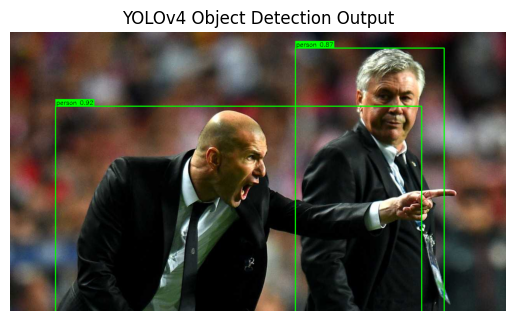

In [ ]:
import matplotlib.pyplot as plt

# Convert BGR (OpenCV format) to RGB (Matplotlib format)
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("YOLOv4 Object Detection Output")
plt.show()

# Yolo v8 Demonstration

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.1 MB/s eta 0:00:00



image 1/1 /content/crosswalk-featured.jpg: 448x640 6 persons, 9 cars, 3 handbags, 825.1ms
Speed: 18.9ms preprocess, 825.1ms inference, 8.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/out/yolov8_demo2


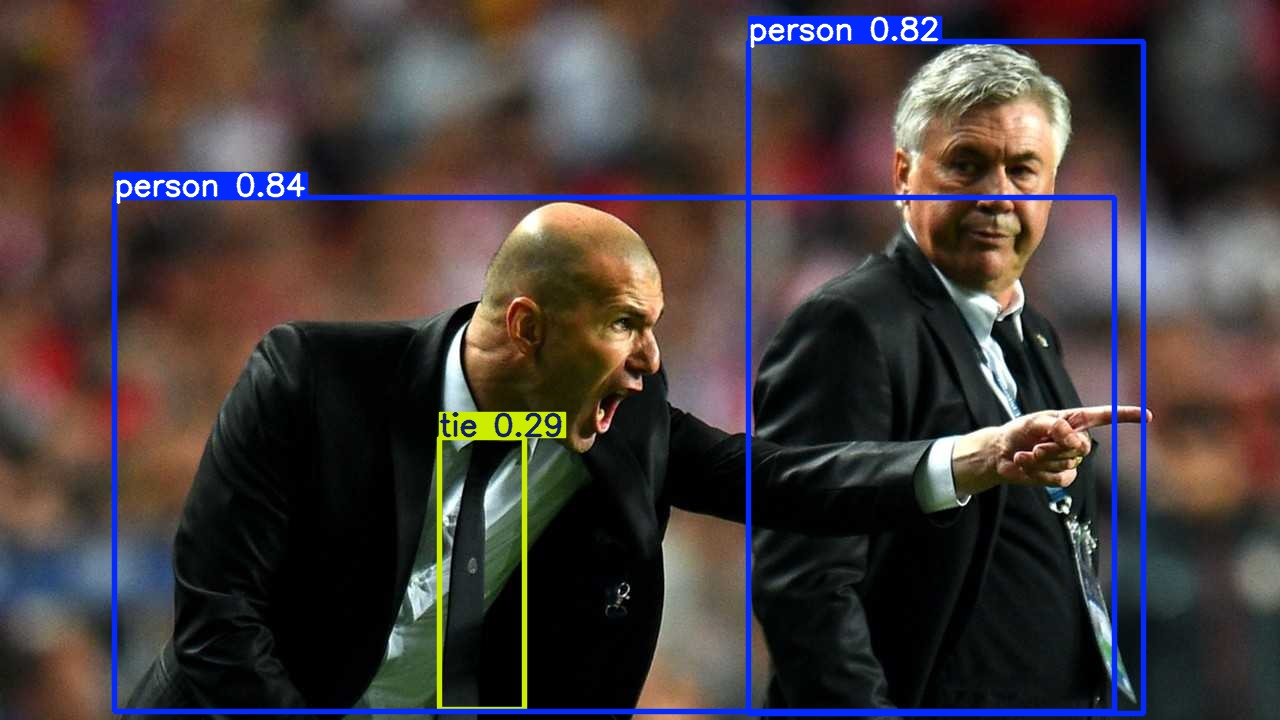

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Load pretrained model
model = YOLO("yolov8n.pt")   # or yolov8s.pt, yolov8m.pt, yolov8x.pt

# 2. Inference
results = model.predict(source="https://callsam.com/wp-content/uploads/2019/12/crosswalk-featured.jpg",
                        conf=0.25, iou=0.45, imgsz=640, save=True, project="out", name="yolov8_demo")

# 3. Display
display(Image(filename="out/yolov8_demo/zidane.jpg"))
